# Preprocessing and Analysis

This section prepares the data before feeding it into machine learning models.

## Required Libraries

This part includes the necessary Python libraries for data processing, machine learning, and visualization. 

In [1]:
# required libraries
import os
import math
import time
from pathlib import Path
import tempfile
import functools
import pandas as pd
import numpy as np
import geopandas as gpd
import statistics
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, max_error, mean_absolute_error, precision_recall_curve, roc_curve, auc
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
pd.set_option("display.max_rows", None)
import scipy, joblib
import scipy.signal
import scipy.stats
from scipy import stats
from scipy.stats import pearsonr
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import confusion_matrix,  classification_report, roc_auc_score, accuracy_score, ConfusionMatrixDisplay
from sklearn.svm import SVC
from xgboost import XGBClassifier
import xgboost as xg
from matplotlib.pyplot import figure
from matplotlib import pyplot
from IPython.display import display, clear_output
import logging
import keras
from keras.models import Sequential
import keras.backend as k
from keras.layers import Dense, GRU, LSTM, Activation, Masking, Dropout, BatchNormalization,Conv1D
from keras.callbacks import History
import keras.optimizers 
from keras import callbacks
#!pip install xgboost
from meteostat import Point, Daily, Hourly
from datetime import datetime, timedelta
import urllib
from urllib.error import HTTPError
import pickle
import requests
import folium
from folium.plugins import HeatMap, Draw, HeatMapWithTime
from tqdm.contrib.concurrent import process_map
from shapely.geometry import Point
import uuid
import pyarrow as pa
import pyarrow.parquet as pq
import shap
import warnings
warnings.filterwarnings('ignore')

2025-08-05 07:40:52.145143: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-05 07:40:52.148185: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-05 07:40:52.157327: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754379652.173670  637237 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754379652.178158  637237 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-05 07:40:52.195309: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

In [2]:
cache_dir = "data"
cache_dir = Path(tempfile.gettempdir()) if cache_dir is None else Path(cache_dir)
        
# make cache dir
cache_dir.mkdir(exist_ok=True, parents=True)

## Loading Final Generated Data

In [2]:
# final generated dataset is "train_ecoliall51_weather"
#datasetxx = pd.read_csv('data/train_ecoliall51_weather.csv')
table2 = pq.read_table('data/train_ecoliall51_weather.parquet')
datasetxx = table2.to_pandas()
datasetxx.shape

(21064, 71)

In [3]:
datasetxx.head()

,Temp Water,Sld Sus@105C,Ammonia(N),Nitrate-N,Nitrite-N,Lat,Long,Phosphate,lst,fpar,...,short_rad_sum_d7,et0_fao_evap_d7,land_cover,agri,forest,grass,wetland,build,others,distance_to_coast
0,21.00,18.0,0.100,1.670,0.028,53.187885,-2.883970,0.231,27.68760,0.579429,...,178.79,31.926334,11,39.883288,1.407847,35.027289,0.000000,23.681575,0.0,45916.922790
1,13.70,5.3,1.370,0.900,0.100,52.709958,-0.600205,0.036,10.16280,0.583827,...,46.19,9.526622,11,76.871670,7.027321,5.712091,0.000000,10.388918,0.0,87128.997072
2,17.23,7.0,0.052,9.440,0.009,55.548733,-1.632261,0.054,21.31200,0.707368,...,140.20,23.048634,11,60.831653,1.083720,28.709003,4.850200,4.525425,0.0,151.798072
3,12.30,16.0,0.165,10.300,0.086,54.083585,-0.194547,0.020,16.30125,0.434800,...,107.10,20.048218,11,71.675393,1.458110,8.628803,3.791887,14.445806,0.0,648.649045
4,16.40,40.0,35.000,0.187,0.036,54.070216,-0.227559,0.830,16.13000,0.351194,...,107.10,20.048218,11,78.999860,0.812048,6.575654,2.715112,10.897326,0.0,2759.274344


In [337]:
datasetxx.columns

Index(['Temp Water', 'Sld Sus@105C', 'Ammonia(N)', 'Nitrate-N', 'Nitrite-N',
       'Lat', 'Long', 'Phosphate', 'lst', 'fpar', 'emis31', 'lai',
       'samplesamplingPoint', 'samplingPointnotation', 'timedate', 'time',
       'date', 'E.coli C-MF', 'temperature_11am', 'humidity_11am',
       'windspeed_11am', 'windgusts_11am', 'winddirection_11am',
       'precipitation_11am', 'rain_11am', 'snowfall_11am', 'cloudcover_11am',
       'pressure_msl_11am', 'soil_temp_7cm', 'soil_moist_7cm', 'vap_press_def',
       'et0_fao_evap', 'sun_duration', 'global_tilted_irr', 'short_rad',
       'dir_rad', 'dew_point_2m', 'temp_min', 'temp_max', 'precipitation_sum',
       'rain_sum', 'snowfall_sum', 'windspeed_max', 'windgusts_max',
       'winddirection_dominant', 'precipitation_hours', 'sunshine_duration_d',
       'daylight_duration_d', 'short_rad_sum_d', 'et0_fao_evap_d', 'temp_min7',
       'temp_max7', 'precipitation_sum7', 'rain_sum7', 'snowfall_sum7',
       'windspeed_max7', 'windgusts_max

## Outlier Removal

Generate season and time columns, and adds inland and coastal area seperation instead of distance to coast. Later, removes outlier samples. Outliers can significantly impact model performance. This step involves detecting and removing extreme values using Z-score analysis.

In [3]:
datasetxxt = datasetxx.drop(['timedate', 'samplingPointnotation', 'samplesamplingPoint'], axis=1)

datasetxxt['season'] = pd.DatetimeIndex(datasetxxt['date']).month%12 // 3 + 1 # Season
datasetxxt['time'] = pd.DatetimeIndex(datasetxxt['time']).hour
# considers sampling location with less than 5km distance from coast as coastal and rest as inland sampling location
datasetxxt['distance_to_coast'] = datasetxxt['distance_to_coast'].apply(lambda x: 0 if x<=5000 else 1)
datasetxxt = datasetxxt.dropna().reset_index(drop=True)

a = np.array(datasetxxt['E.coli C-MF'].values)
#datasetxxt['E.coli C-MF'] = np.where(a > 10000, 10000, a) # replace values with higher than 10k with 10k (can be deleted based on need)
# outlier removal using Z-score
for i in datasetxxt.columns:
    if not i == 'date':
        z = np.abs(stats.zscore(datasetxxt[i]))
        outlier_indices = np.where(z > 15)[0]
        print(datasetxxt[i][outlier_indices])
        datasetxxt = datasetxxt.drop(outlier_indices).reset_index(drop=True)
datasetxxt.shape

Series([], Name: Temp Water, dtype: float64)
2637      2430.0
2662      4950.0
11479     4890.0
13265     1950.0
13352     3610.0
14965     4970.0
16124     5610.0
18633    10000.0
Name: Sld Sus@105C, dtype: float64
1718      71.7
5846     134.0
7560     134.0
7707     198.0
11345    494.0
17290     79.3
17678    134.0
Name: Ammonia(N), dtype: float64
Series([], Name: Nitrate-N, dtype: float64)
864      1.10
1826     3.30
2493     5.20
2615     2.45
19389    1.50
19817    2.80
Name: Nitrite-N, dtype: float64
Series([], Name: Lat, dtype: float64)
Series([], Name: Long, dtype: float64)
20362    31.0
20699    31.0
Name: Phosphate, dtype: float64
Series([], Name: lst, dtype: float64)
Series([], Name: fpar, dtype: float64)
Series([], Name: emis31, dtype: float64)
Series([], Name: lai, dtype: float64)
Series([], Name: time, dtype: int32)
7632     4700000.0
15058    8727273.0
19539    1200000.0
Name: E.coli C-MF, dtype: float64
Series([], Name: temperature_11am, dtype: float64)
Series([], Nam

(20969, 69)

In [4]:
datasetxxt.columns

Index(['Temp Water', 'Sld Sus@105C', 'Ammonia(N)', 'Nitrate-N', 'Nitrite-N',
       'Lat', 'Long', 'Phosphate', 'lst', 'fpar', 'emis31', 'lai', 'time',
       'date', 'E.coli C-MF', 'temperature_11am', 'humidity_11am',
       'windspeed_11am', 'windgusts_11am', 'winddirection_11am',
       'precipitation_11am', 'rain_11am', 'snowfall_11am', 'cloudcover_11am',
       'pressure_msl_11am', 'soil_temp_7cm', 'soil_moist_7cm', 'vap_press_def',
       'et0_fao_evap', 'sun_duration', 'global_tilted_irr', 'short_rad',
       'dir_rad', 'dew_point_2m', 'temp_min', 'temp_max', 'precipitation_sum',
       'rain_sum', 'snowfall_sum', 'windspeed_max', 'windgusts_max',
       'winddirection_dominant', 'precipitation_hours', 'sunshine_duration_d',
       'daylight_duration_d', 'short_rad_sum_d', 'et0_fao_evap_d', 'temp_min7',
       'temp_max7', 'precipitation_sum7', 'rain_sum7', 'snowfall_sum7',
       'windspeed_max7', 'windgusts_max7', 'winddirection_dominant7',
       'precipitation_hours7', 'suns

## Data Split

The dataset is split into training and testing sets, ensuring that the model generalizes well to unseen data. The split ratio is 85-15.

Two training approach considered: 

**Random Geographic Split Training:** Trained on most of catchments and tested on the rest unseen catchments.
This method is suitable when new unseen catchments are under study.

**Random Temporal Split Training:** Trained on 85% of data samples for all catchments and tested on the remaining 15% of the dataset.
This method is suitable when current trained catchments are under study.

Choose the desired split and remove the other part:

In [5]:
#datasetxxt['E.coli C-MF'] = np.log10(datasetxxt['E.coli C-MF'])
#datasetxxt = datasetxxt.sort_values(by='date').reset_index(drop=True) # to sort by date
y = datasetxxt['E.coli C-MF']
X = datasetxxt.drop(['E.coli C-MF','Lat', 'Long', 'date'], axis=1)#"snowfall_11am", "snowfall_sum","lai","rain_11am","rain_sum","rain_sum7"]
"""
# for Geographical Split
locations = datasetxxt[['Lat', 'Long']].drop_duplicates()
train_l, test_l = train_test_split(locations, test_size=0.15, random_state=41)
train = pd.merge(datasetxxt, train_l, on=['Lat', 'Long'])
test = pd.merge(datasetxxt, test_l, on=['Lat', 'Long'])
print('Number of training catchments: %.0f' %  train['Lat'].nunique())
print('Number of testing catchments: %.0f' %  test['Lat'].nunique())

X_train = train.drop(['E.coli C-MF','Lat', 'Long', 'date'], axis=1) #,"snowfall_11am", "snowfall_sum"
X_test = test.drop(['E.coli C-MF','Lat', 'Long', 'date'], axis=1) #,"snowfall_11am", "snowfall_sum"
y_train, y_test = train['E.coli C-MF'], test['E.coli C-MF']
"""

# for Temporal Split
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, shuffle=False) # if sorted by date
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42) # to shuffle


# replace values with higher than 10k with 10k (can be deleted based on need)
# helps the model to focus on lower E.coli consentration
a = np.array(y_train.values)
y_train = np.where(a > 10000, 10000, a) 

In [6]:
X_test.shape

(3146, 65)

### Show test and train locations on the map for Geographical Split

In [189]:
# Show test and train locations on the map for Geographical Split
import folium
import pandas as pd
import branca.colormap as cm
from scipy import stats
from utils import getradius1

grouped_data = train[['E.coli C-MF','Long','Lat']]
grouped_data = grouped_data.dropna().reset_index(drop=True)
grouped_data = grouped_data.groupby(["Lat", "Long"]).agg(
    ecoli_mean = ("E.coli C-MF","mean"),
    ecoli_count = ("E.coli C-MF","count")
).reset_index()

# Sample data generation (Replace this with your actual DataFrame)
df = grouped_data
df = df[df['Lat'] > 49.90] #Drop unwanted rows
df = df[df['Lat'] < 61] #Drop unwanted rows


m = folium.Map(location=[df['Lat'].median(), df['Long'].median()], zoom_start=5)

colormap = cm.LinearColormap(colors=['green', 'yellow'], vmin=0, vmax=1000000)

# Add circle markers for each location
for index, row in df.iterrows():
    folium.CircleMarker(
        location=[row['Lat'], row['Long']],
        radius= getradius1(row['ecoli_count']*100),  # Scale the radius according to the counts
        color=colormap(row['ecoli_mean']),  # Assign color based on intensity
        fill=True,
        fill_opacity=0.6,
        popup=f"Intensity: {row['ecoli_mean']}"
    ).add_to(m)
    
grouped_data = test[['E.coli C-MF','Long','Lat']]
grouped_data = grouped_data.dropna().reset_index(drop=True)
grouped_data = grouped_data.groupby(["Lat", "Long"]).agg(
    ecoli_mean = ("E.coli C-MF","mean"),
    ecoli_count = ("E.coli C-MF","count")
).reset_index()

# Sample data generation (Replace this with your actual DataFrame)
df = grouped_data
df = df[df['Lat'] > 49.90] #Drop unwanted rows
df = df[df['Lat'] < 61] #Drop unwanted rows

colormap = cm.LinearColormap(colors=['red', 'yellow'], vmin=0, vmax=10000000)


for index, row in df.iterrows():
    folium.CircleMarker(
        location=[row['Lat'], row['Long']],
        radius= getradius1(row['ecoli_count']*100),  # Scale the radius according to the counts
        color=colormap(row['ecoli_mean']),  # Assign color based on intensity
        fill=True,
        fill_opacity=0.6,
        popup=f"Intensity: {row['ecoli_mean']}"
    ).add_to(m)

# Save map to an HTML file
m.save('ecoli_l.html')

m

## Distribution Analysis

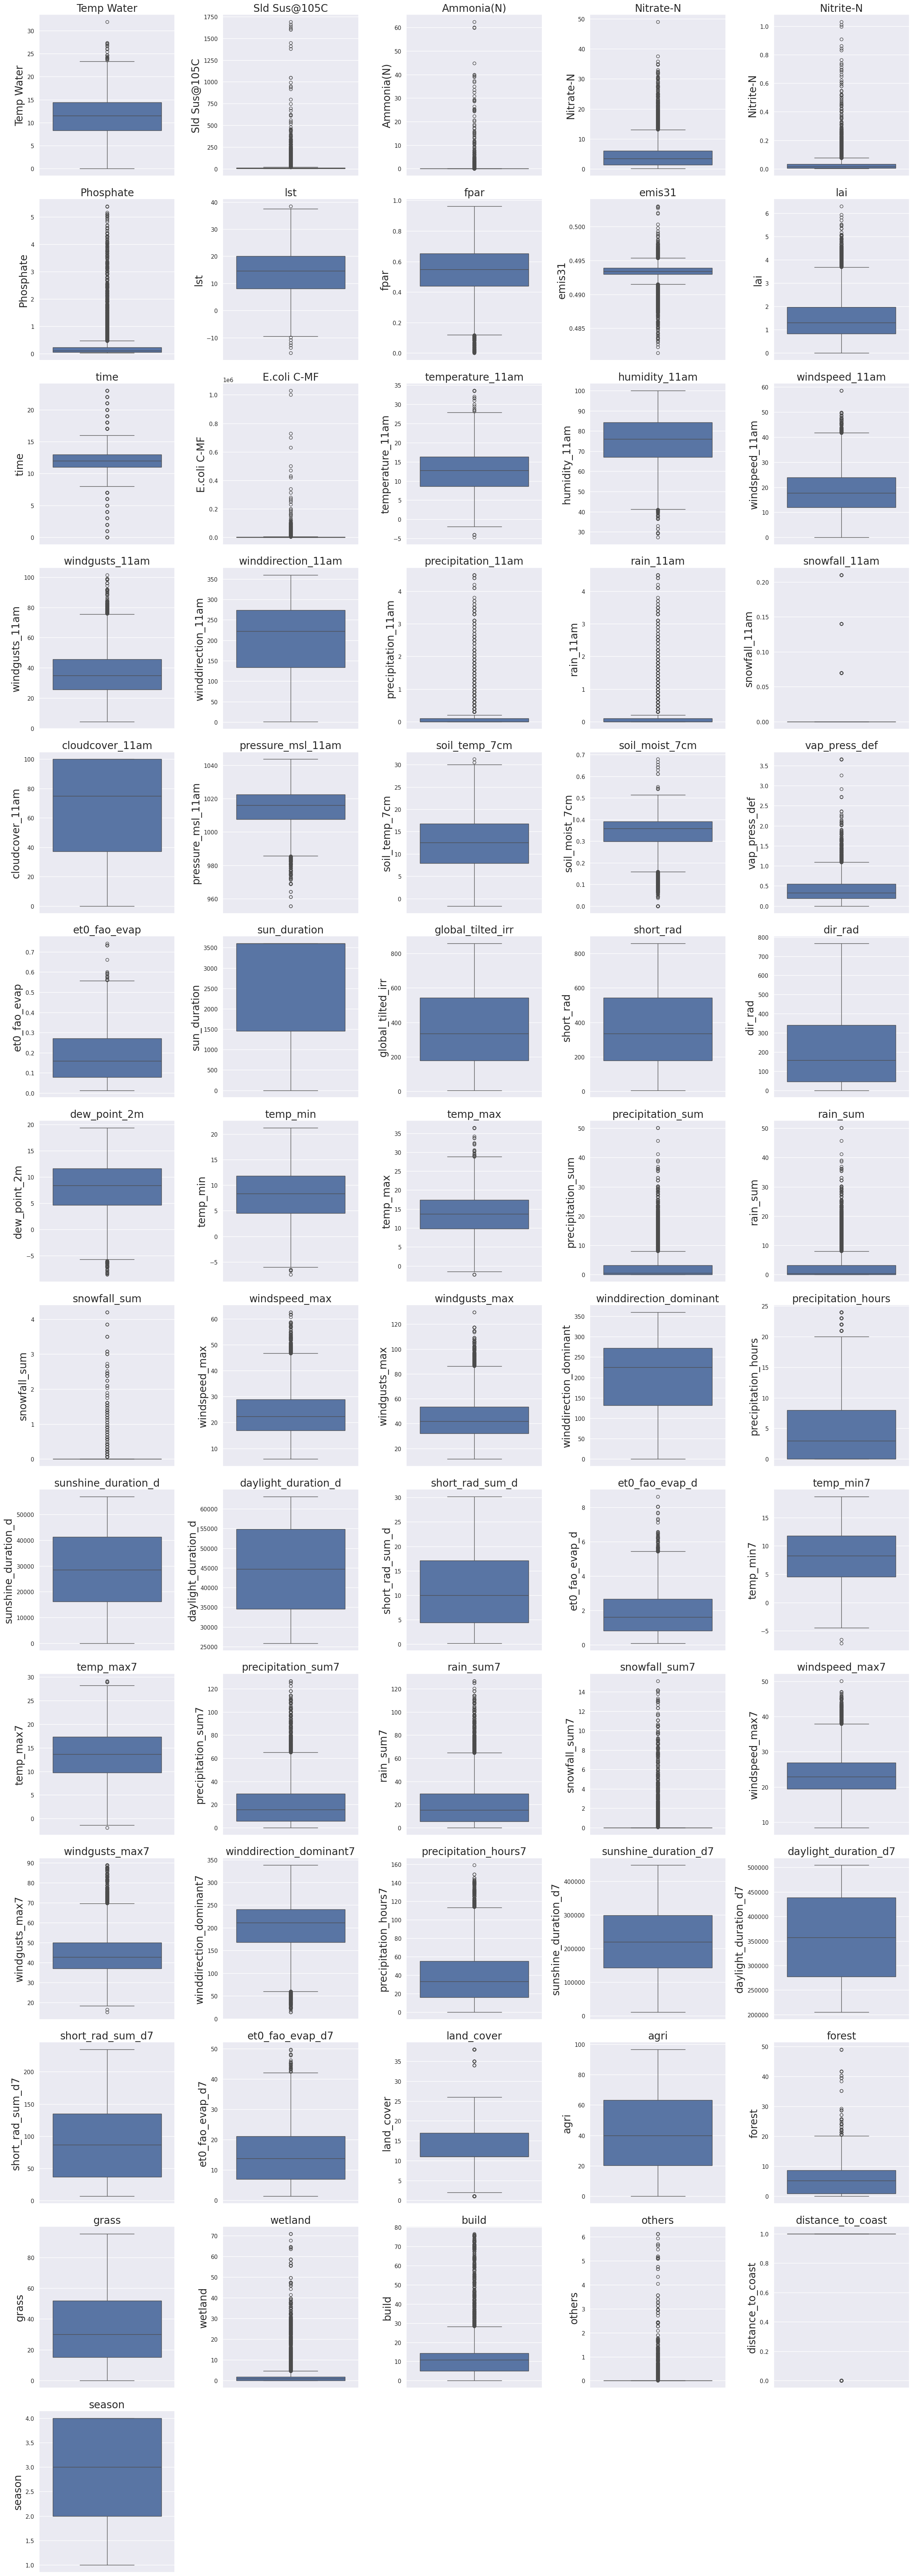

In [72]:
# distribution analysis
def plot_boxplots(df):
    i = 5
    num_columns = len(df.columns)
    num_rows = math.ceil(num_columns/i)
    
    fig, axes = plt.subplots(nrows=num_rows, ncols=min(i,num_columns), figsize=(5*min(i,num_columns), 5*num_rows))
    
    plt.rcParams['font.size'] = '16'
    axes = axes.flatten()
    if num_columns == 1:
        axes = [axes]

    for i, col in enumerate(df.columns):
        sns.boxplot(data=df, y=col, ax=axes[i])
        axes[i].set_title(f'{col}' , fontsize=20)
        axes[i].set_ylabel(col, fontsize=20)
    
    for i in range(num_columns, len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()

plot_boxplots(datasetxxt.drop(['Lat', 'Long', 'date'], axis=1))

In [16]:
# this code duplicates the minority class (Ecoli > 1000)(can be ignored, didnt improved the model performance)

X2 = pd.concat([X_train.reset_index(drop=True),pd.DataFrame({'E.coli C-MF': y_train})],axis=1)
# Define the threshold to filter for minority class (Ecoli > 1000)
df_majority = X2[X2['E.coli C-MF'] <= 1000]
df_minority = X2[X2['E.coli C-MF'] > 1000]

# Calculate how many times to duplicate the minority class to match the size of the majority class
majority_count = len(df_majority)
minority_count = len(df_minority)

# Duplicate the minority class to balance the dataset
duplication_factor = majority_count // minority_count
df_minority_duplicated = pd.concat([df_minority] * duplication_factor, ignore_index=True)

# If there's still a difference, we randomly sample the remaining instances
remaining_samples = majority_count - len(df_minority_duplicated)
if remaining_samples > 0:
    df_minority_duplicated = pd.concat([df_minority_duplicated, df_minority.sample(remaining_samples, replace=True)], ignore_index=True)

# Combine the duplicated minority data with the majority data
df_balanced = pd.concat([df_majority, df_minority_duplicated], axis=0).reset_index(drop=True)

# Shuffle the dataset to ensure random distribution
X2 = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
y_train = X2['E.coli C-MF']
X_train = X2.drop(['E.coli C-MF'], axis=1)

len(X2) # was not helping

23920

## Feature Importance

Feature importance analysis determines which variables contribute most to predictions. Techniques like Random Forest Feature Importance or XGBoost’s built-in feature importance are common.

Temp Water Score: 0.01234
Sld Sus@105C Score: 0.16014
Ammonia(N) Score: 0.07088
Nitrate-N Score: 0.03453
Nitrite-N Score: 0.02114
Phosphate Score: 0.05089
lst Score: 0.01298
fpar Score: 0.01300
emis31 Score: 0.01742
lai Score: 0.01187
time Score: 0.00779
temperature_11am Score: 0.00650
humidity_11am Score: 0.01210
windspeed_11am Score: 0.00807
windgusts_11am Score: 0.01059
winddirection_11am Score: 0.00950
precipitation_11am Score: 0.00363
rain_11am Score: 0.00331
snowfall_11am Score: 0.00011
cloudcover_11am Score: 0.00658
pressure_msl_11am Score: 0.02508
soil_temp_7cm Score: 0.00832
soil_moist_7cm Score: 0.02961
vap_press_def Score: 0.00834
et0_fao_evap Score: 0.00667
sun_duration Score: 0.00123
global_tilted_irr Score: 0.00476
short_rad Score: 0.00616
dir_rad Score: 0.00565
dew_point_2m Score: 0.01605
temp_min Score: 0.01577
temp_max Score: 0.00727
precipitation_sum Score: 0.01653
rain_sum Score: 0.02341
snowfall_sum Score: 0.00056
windspeed_max Score: 0.01018
windgusts_max Score: 0.

<Axes: xlabel='Importance', ylabel='Feature'>

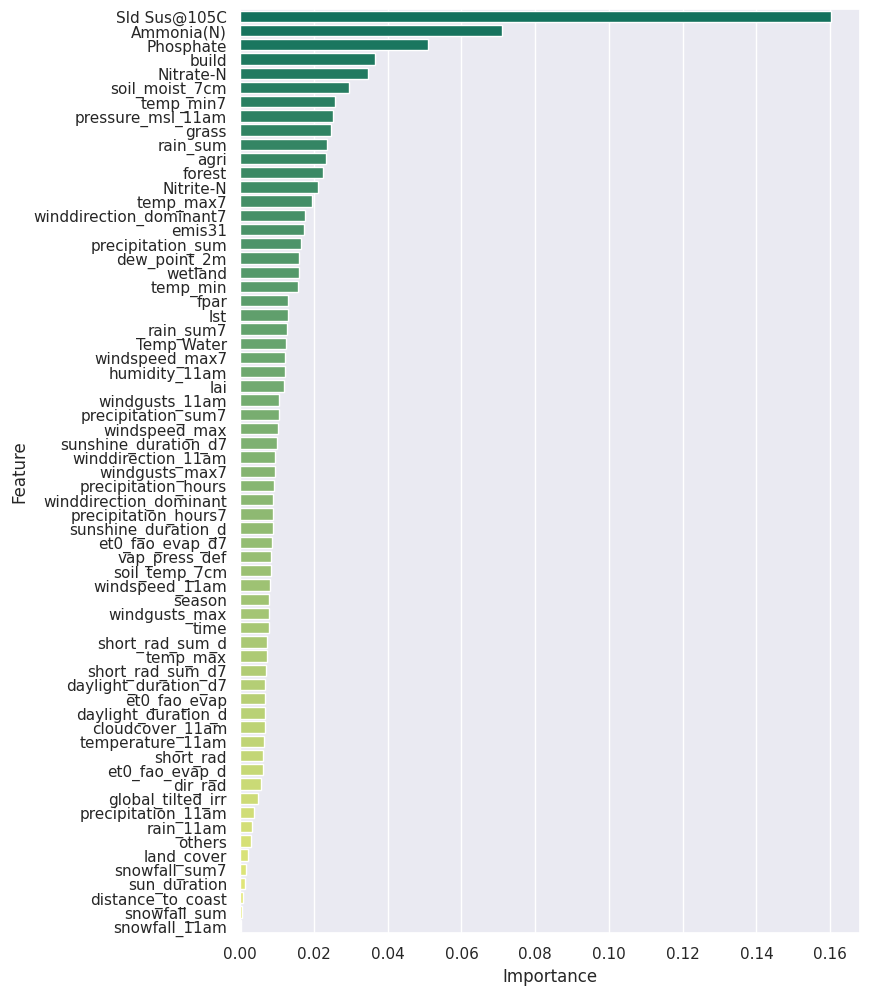

In [73]:
# feature importance analysis
#model = xg.XGBRegressor()
model = RandomForestRegressor(n_estimators=10)
# fit the model
model.fit(X_train, y_train)
# get importance
importance = model.feature_importances_
# summarize feature importance
for i,v in enumerate(importance):
    print(X.columns[i] + ' Score: %.5f' % (v))
# plot feature importance
temp = pd.concat([pd.Series(X.columns),pd.Series(model.feature_importances_)],axis=1)
temp.columns = ['Feature','Importance']
temp = temp.sort_values('Importance',ascending=False)
plt.figure(figsize=(8,12))
sns.barplot(x='Importance',y='Feature',data=temp,orient='h',palette='summer')

Temp Water Score: 0.05000
Sld Sus@105C Score: 0.12552
Ammonia(N) Score: 0.04519
Nitrate-N Score: -0.05124
Nitrite-N Score: 0.04791
Lat Score: 0.04482
Long Score: -0.05267
Phosphate Score: 0.06305
lst Score: 0.02525
fpar Score: 0.01385
emis31 Score: 0.01993
lai Score: 0.02515
E.coli C-MF Score: 1.00000
temperature_11am Score: 0.03740
humidity_11am Score: 0.05896
windspeed_11am Score: 0.03937
windgusts_11am Score: 0.04669
winddirection_11am Score: 0.01236
precipitation_11am Score: 0.09900
rain_11am Score: 0.09917
snowfall_11am Score: -0.00059
cloudcover_11am Score: 0.04956
pressure_msl_11am Score: -0.08389
soil_temp_7cm Score: 0.03935
soil_moist_7cm Score: 0.05142
vap_press_def Score: -0.03250
et0_fao_evap Score: -0.01783
sun_duration Score: -0.03941
global_tilted_irr Score: -0.02076
short_rad Score: -0.02076
dir_rad Score: -0.02558
dew_point_2m Score: 0.06994
temp_min Score: 0.06807
temp_max Score: 0.03442
precipitation_sum Score: 0.14082
rain_sum Score: 0.14091
snowfall_sum Score: 0.00

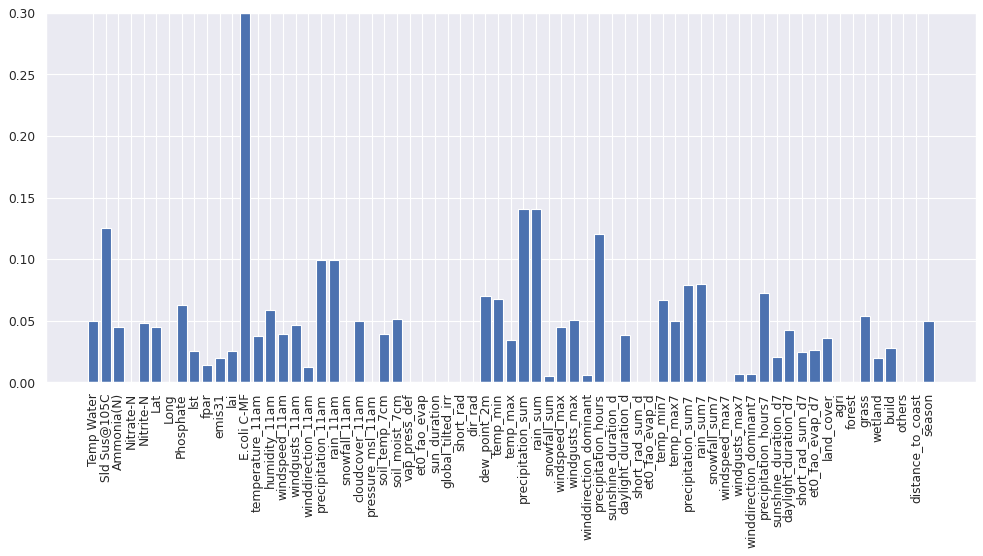

In [74]:
list2 = datasetxxt['E.coli C-MF']
columns = datasetxxt.drop(['date','time'], axis=1).columns
corr = []
for i, v in enumerate(columns):
    list1 = datasetxxt[v].to_numpy()
    # Apply the pearsonr()
    nas = np.logical_or(pd.isnull(list1), pd.isnull(list2))
    cor, _ = pearsonr(list1[~nas], list2[~nas])
    print(columns[i] + ' Score: %.5f' % (cor))
    corr.append(cor)

figure(figsize=(15, 6), dpi=80)
pyplot.bar([x for x in range(len(corr))], corr)
pyplot.xticks(range(len(corr)), columns, rotation=90)
pyplot.ylim(0,0.3)
pyplot.show()

## Normalization

Data normalization ensures that all numerical features are on a similar scale, preventing models from being biased toward large-valued features. MinMax scaling or Standard scaling (Z-score normalization) is used.

The Normalization scales are saved to be used in the inference phase.

In [8]:
Scaler = MinMaxScaler().fit(X_train)#MinMaxScaler
X_trainN = Scaler.transform(X_train)
Scaler1 = MinMaxScaler().fit(y_train.reshape(-1, 1))
y_trainN = Scaler1.transform(y_train.reshape(-1, 1))
"""
scaler_filename = "Model/Scaler_Tmp_adv.save"
joblib.dump(Scaler, scaler_filename) 
scaler_filename = "Model/Scaler1_Tmp_adv.save"
joblib.dump(Scaler1, scaler_filename)
"""
X_testN = Scaler.transform(X_test)
y_testN = Scaler1.transform(y_test.to_numpy().reshape(-1, 1))

In [368]:
# this is a an extra feature importance analysis conducted on train set.
# this approach evaluates different features and selects the set that results in the best model performance based on cross-validation.
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
import warnings
warnings.filterwarnings('ignore')
# Initialize the model
model = xg.XGBRegressor(objective='reg:absoluteerror',n_estimators = 20,seed = 12)

# Initialize Sequential Feature Selector
sfs = SFS(model,
          k_features='best', # can be a number of selected features
          forward=True,
          floating=False,
          scoring='neg_mean_absolute_error',
          cv=5,
         n_jobs=8)

# Fit SFS
sfs = sfs.fit(X_trainN, y_trainN)

# Get the selected features
selected_features = list(sfs.k_feature_names_)
print("Selected features:", selected_features)
# X_trainN[:,[int(i) for i in list(sfs.k_feature_names_)]]

Selected features: ['1', '2', '5', '8', '9', '10', '24', '25', '57', '59']


# E.coli Estimators

This section focuses on different machine learning models used for regression tasks, estimating E. coli concentration (No/100ml).

## XGBRegressor E.coli Estimator

XGBoost (Extreme Gradient Boosting) is a powerful ensemble learning algorithm known for its high accuracy and efficiency in handling structured data.

In [9]:
# XGBRegressor E.coli Estimator
xgboost = xg.XGBRegressor(objective='reg:tweedie',n_estimators = 200,seed = 12) #logistic
xgboost.fit(X_trainN, y_trainN)

#save model
"""
with open('modelxgb.pkl', 'wb') as f:
    pickle.dump(xgboost, f)"""
y_pre_tr = xgboost.predict(X_trainN)

print('Train RMSE:{}'.format(np.sqrt(mean_squared_error(Scaler1.inverse_transform(y_trainN).reshape(-1, 1),
                                                        Scaler1.inverse_transform(y_pre_tr.reshape(-1, 1))))))

Train RMSE:638.0522061574072


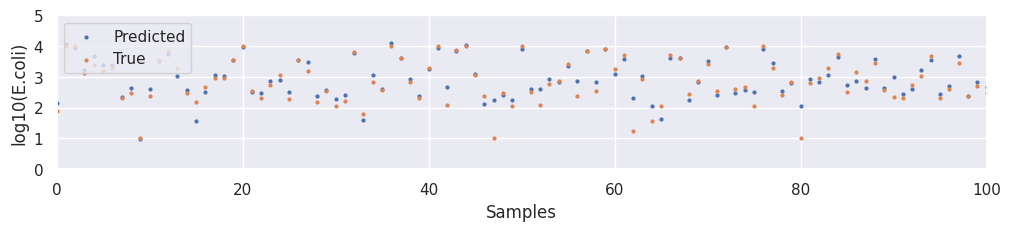

In [10]:
"""
plt.figure(figsize=(10,2))
plt.plot(Scaler1.inverse_transform(y_pre_tr.reshape(-1, 1)), label=' XGBoost Predicted')
plt.plot(y_train,label="True")            
plt.ylabel("E.coli")
plt.xlabel("Sample")
plt.legend(loc='upper left')
plt.ylim(0,10000)
plt.xlim(0,100)
plt.show()
"""
plt.figure(figsize=(12,2))
plt.scatter(range(len(y_pre_tr)),np.log10(Scaler1.inverse_transform(y_pre_tr.reshape(-1, 1))), label='Predicted', s=4)
plt.scatter(range(len(y_pre_tr)),np.log10(Scaler1.inverse_transform(y_trainN).reshape(-1, 1)),label="True", s=4)            
plt.ylabel("log10(E.coli)")
plt.xlabel("Samples")
plt.legend(loc='upper left')
plt.ylim(0,5)
plt.xlim(0,100)
plt.show()

In [11]:
y_pre = xgboost.predict(X_testN)
y_pre = Scaler1.inverse_transform(y_pre.reshape(-1, 1))
y_pre[y_pre<0] = 0 # replace negative prediction with zero


# to calculate RMSE we need to also down scale the test samples as well
a = np.array(y_test.values)
y_test1 = np.where(a > 10000, 10000, a) 

print('Test RMSE:{}'.format(np.sqrt(mean_squared_error(y_test1,
                                                        y_pre))))

Test RMSE:1945.1741011267065


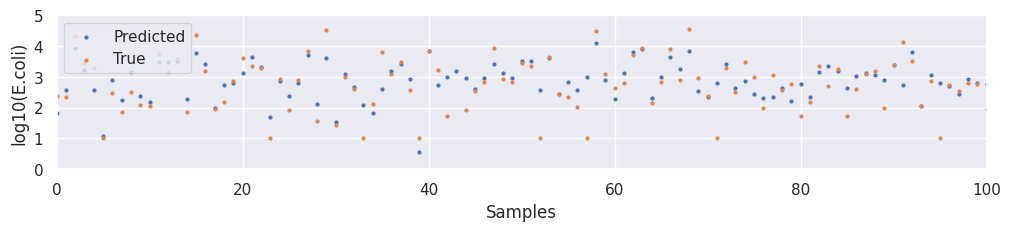

In [12]:
"""plt.figure(figsize=(10,2))
plt.plot( y_pre, label='Predicted')
plt.plot(y_test.to_numpy(),label="True")            
plt.ylabel("E.coli (No/100mL)")
plt.xlabel("Samples")
plt.legend(loc='upper left')
plt.ylim(0,10000)
plt.xlim(0,100)
plt.show()"""

plt.figure(figsize=(12,2))
plt.scatter(range(len(y_pre)),np.log10(y_pre), label='Predicted', s=4)
plt.scatter(range(len(y_test)),np.log10(y_test.to_numpy()),label="True", s=4)            
plt.ylabel("log10(E.coli)")
plt.xlabel("Samples")
plt.legend(loc='upper left')
plt.ylim(0,5)
plt.xlim(0,100)
plt.show()

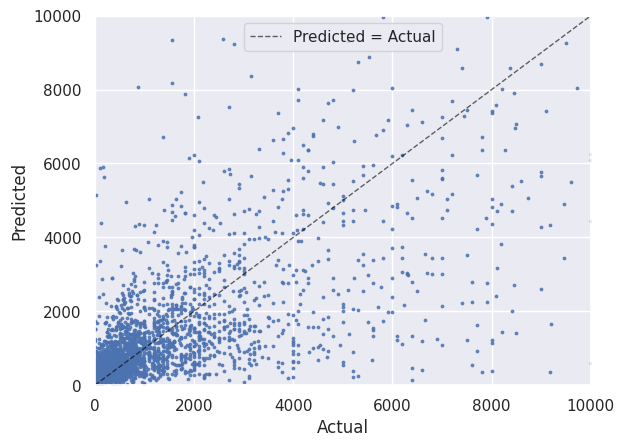

In [13]:
plt.scatter(x=y_test.to_numpy(), y=y_pre, s=3, alpha=0.8)
plt.axline((0, 0),(10000, 10000),color="black",linestyle="--",alpha=0.6,linewidth=1,label="Predicted = Actual",)
plt.xlim(0, 10000)
plt.ylim(0, 10000)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()

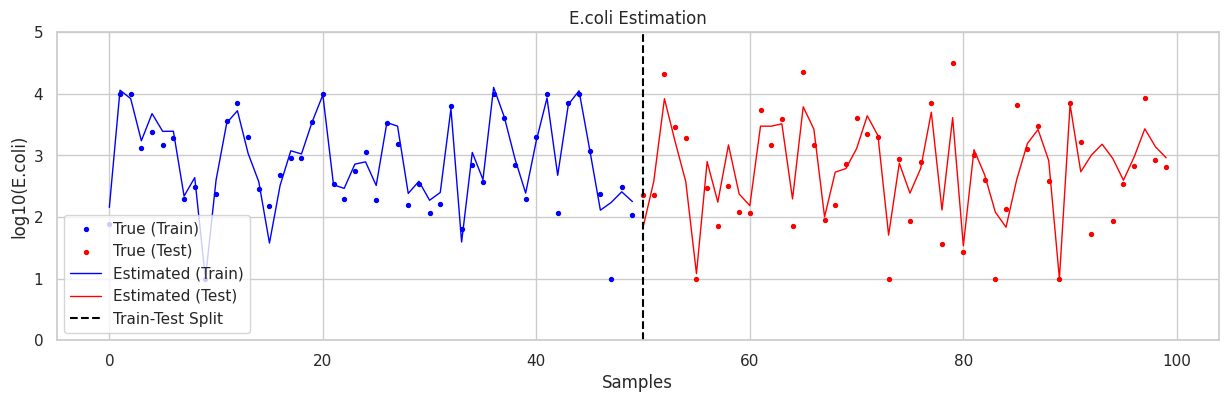

In [14]:
time = np.arange(100)

# Splitting into train and test
split_idx = len(time) // 2
i = split_idx
time_train, time_test = time[:split_idx], time[split_idx:]

tr = Scaler1.inverse_transform(y_pre_tr.reshape(-1, 1))[:i]
tst = y_pre[:i]
tr[tr<10] = 10
tst[tst<10] = 10

# Plot setup
plt.figure(figsize=(15, 4))
sns.set_style("whitegrid")

# Plot true values as dots
plt.scatter(time_train, np.log10(y_train[:i]), color="blue", label="True (Train)", s=8)
plt.scatter(time_test,np.log10(y_test.to_numpy()[:i]), color="red", label="True (Test)", s=8)

# Plot estimated values as a continuous line
plt.plot(time_train,np.log10(tr), color="blue", label="Estimated (Train)", linewidth=1)
plt.plot(time_test,np.log10(tst), color="red", label="Estimated (Test)", linewidth=1)

# Vertical dashed line to mark train-test split
plt.axvline(x=split_idx, color="black", linestyle="--", linewidth=1.5, label="Train-Test Split")

# Labels and legend
plt.xlabel("Samples")
plt.ylabel("log10(E.coli)")
plt.title("E.coli Estimation")
plt.ylim(0, 5)
plt.legend()
plt.show()

### Three classes confusion matrix

col_0,low,moderate,high
row_0,,,
high,0.049869,0.245755,0.769170
moderate,0.448819,0.663092,0.212648
low,0.501312,0.091153,0.018182


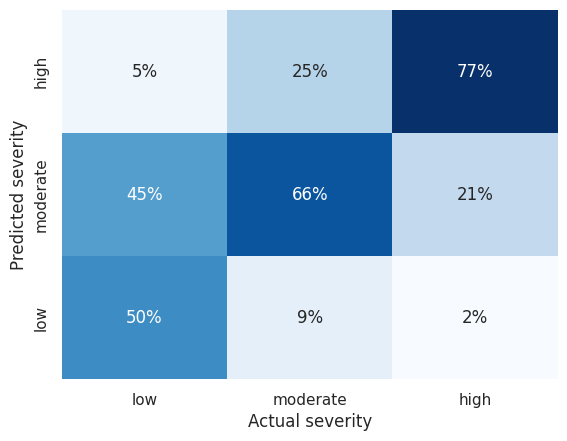

In [16]:
# three classes (x<235, 235<x<1000, 1000<x)
yt_severity = y_test.astype(float).apply(lambda x: ("low" if (x <235)
                                                    else("moderate" if  (1000>=x>=235)
                                                         else "high")))
yp_severity = pd.DataFrame({'ecoli': y_pre.reshape(-1)})['ecoli'].astype(float).apply(lambda x: ("low" if (x <235)
                                                    else("moderate" if  (1000>=x>=235)
                                                         else "high")))

to_plot = pd.crosstab(yp_severity.to_numpy(), yt_severity.to_numpy())
SEVERITY_LEFT_EDGES = {"low": 1, "moderate": 2, "high": 3}
SEVERITY_LEVEL_NAMES = list(SEVERITY_LEFT_EDGES.keys())

# make sure crosstab is even on both axes
for level in SEVERITY_LEVEL_NAMES:
    if level not in to_plot.index:
        to_plot.loc[level, :] = 0
    if level not in to_plot.columns:
        to_plot[level] = 0

# reverse index order for plotting
to_plot = to_plot.loc[SEVERITY_LEVEL_NAMES[::-1], SEVERITY_LEVEL_NAMES]
fmt = ",.0f"

normalize = True
if normalize:
    to_plot = to_plot / to_plot.sum()
    fmt = ".0%"

sns.heatmap(to_plot, cmap="Blues", annot=True, fmt=fmt, cbar=False)
plt.xlabel("Actual severity")
plt.ylabel("Predicted severity")
to_plot

### Two classes confusion matrix

col_0         low-moderate  high
row_0                           
high                   286  1000
low-moderate          1551   309
Performance accuracy: 0.81087


Text(46.24999999999999, 0.5, 'Predicted severity')

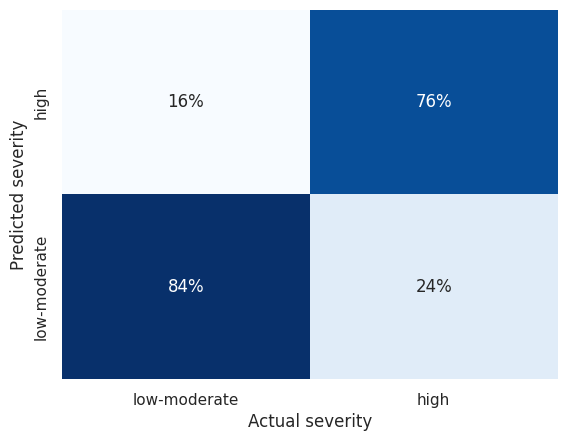

In [17]:
# two classes (x<thr, thr<x)
# U can change the threshold by choosing "thr" value
thr = 1000
yt_severity = y_test.astype(float).apply(lambda x: ("low-moderate" if (x <thr)
                                                         else "high"))
yp_severity = pd.DataFrame({'ecoli': y_pre.reshape(-1)})['ecoli'].astype(float).apply(
    lambda x: ("low-moderate" if (x <thr) else "high"))

to_plot = pd.crosstab(yp_severity.to_numpy(), yt_severity.to_numpy())
SEVERITY_LEFT_EDGES = {"low-moderate": 1, "high": 2}
SEVERITY_LEVEL_NAMES = list(SEVERITY_LEFT_EDGES.keys())

# make sure crosstab is even on both axes
for level in SEVERITY_LEVEL_NAMES:
    if level not in to_plot.index:
        to_plot.loc[level, :] = 0
    if level not in to_plot.columns:
        to_plot[level] = 0

# reverse index order for plotting
to_plot = to_plot.loc[SEVERITY_LEVEL_NAMES[::-1], SEVERITY_LEVEL_NAMES]
fmt = ",.0f"
print(to_plot)
print("Performance accuracy: %.5f" % ((to_plot['high']['high'] + to_plot['low-moderate']['low-moderate'])/y_test.size))
Accuarcy = ((to_plot['high']['high'] + to_plot['low-moderate']['low-moderate'])/y_test.size)

normalize = True
if normalize:
    to_plot = to_plot / to_plot.sum()#.sum()
    fmt = ".0%"

sns.heatmap(to_plot, cmap="Blues", annot=True, fmt=fmt, cbar=False)
plt.xlabel("Actual severity")
plt.ylabel("Predicted severity")

importance_type:
- **weight** - the number of times a feature is used to split the data across all trees.
- **gain** - the average gain across all splits the feature is used in.
- **cover** - the average coverage across all splits the feature is used in.
- **total_gain** - the total gain across all splits the feature is used in.
- **total_cover** - the total coverage across all splits the feature is used in.

<Axes: xlabel='Normalized Importance', ylabel='Feature'>

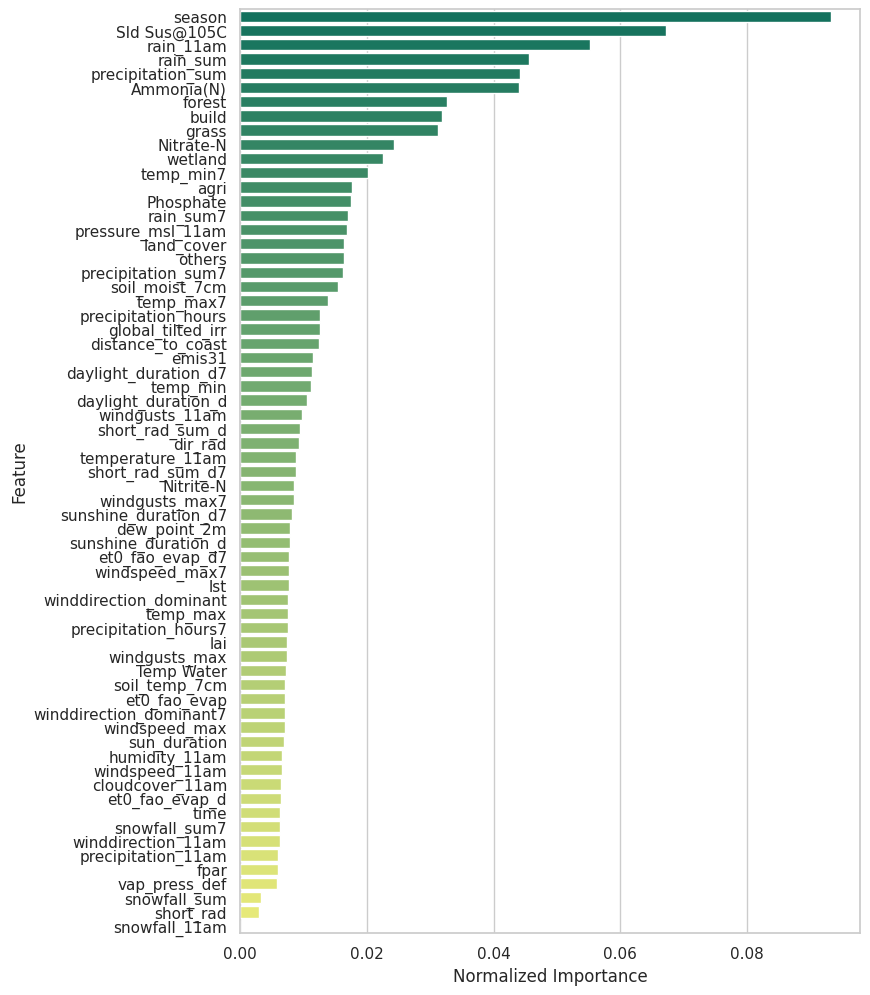

In [18]:
importance_type = 'Normalized Importance'

if importance_type=='Normalized Importance':
    importance = xgboost.feature_importances_ # return "weights" that sum up to one.
    temp = pd.concat([pd.Series(X.columns),pd.Series(importance)],axis=1)
else:
    importance = xgboost.get_booster().get_score(importance_type=importance_type)
    temp = pd.concat([pd.Series(X.columns),pd.Series(importance.values())],axis=1)

# plot feature importance
temp.columns = ['Feature',importance_type]
temp = temp.sort_values(importance_type,ascending=False)
plt.figure(figsize=(8,12))
sns.barplot(x=importance_type,y='Feature',data=temp,orient='h',palette='summer')

# SHAP Analysis

In [19]:
explainer = shap.Explainer(xgboost, X_trainN)
shap_values = explainer.shap_values(X_testN)

 99%|===================| 3126/3146 [00:20<00:00]        

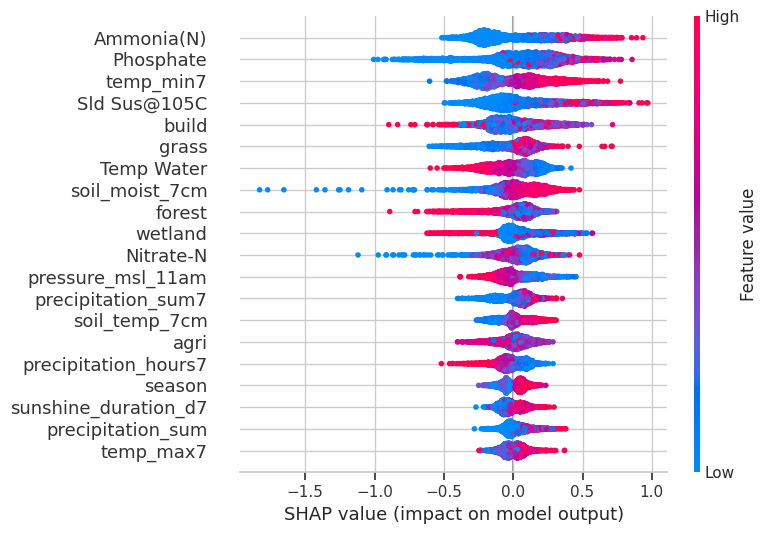

In [20]:
shap.summary_plot(shap_values, X_testN,feature_names=X_test.columns,plot_size=0.2)

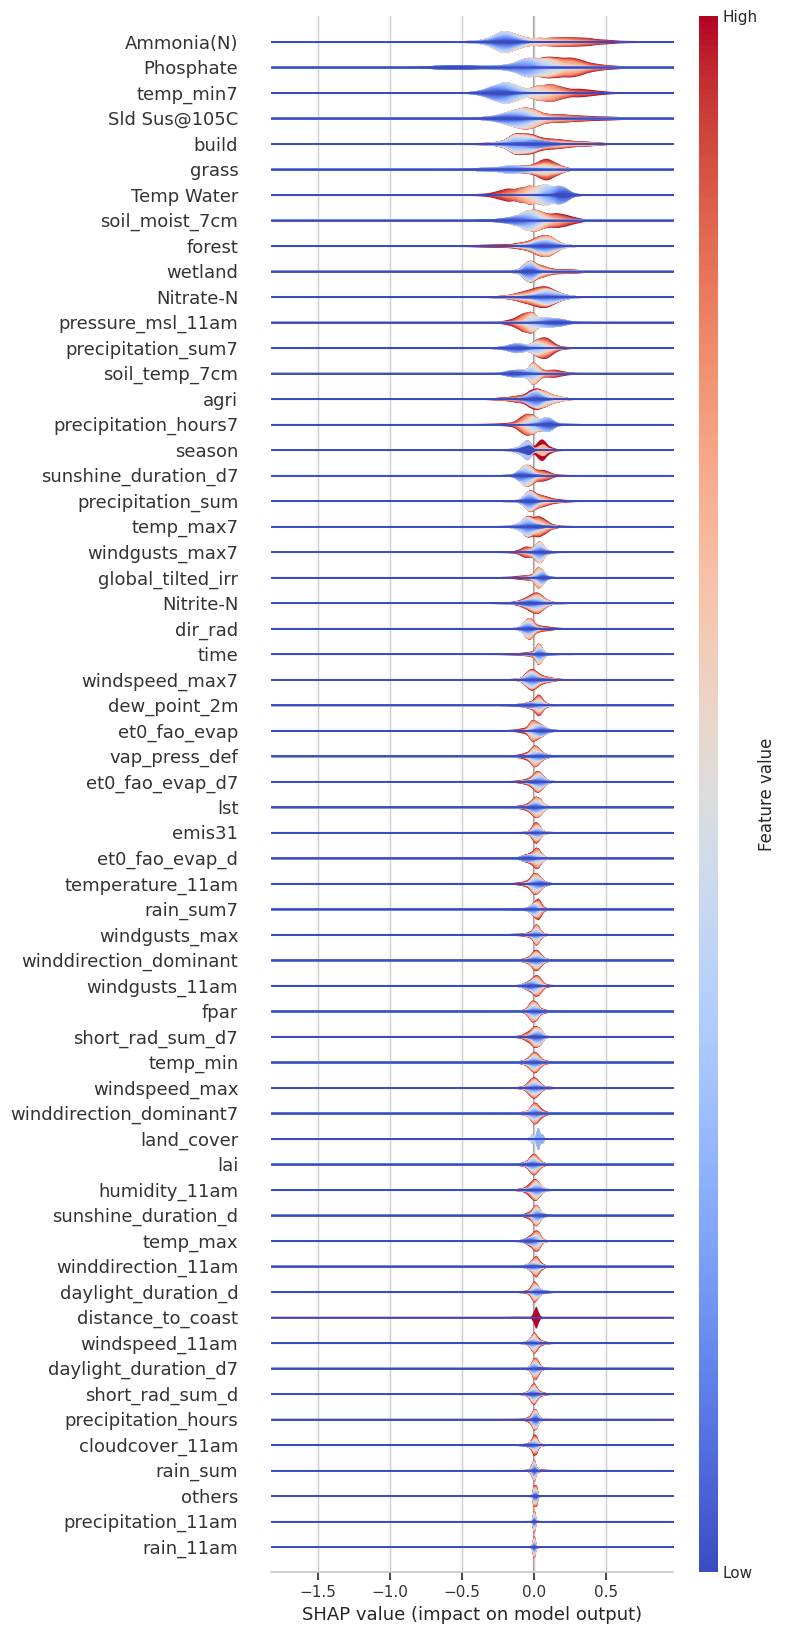

In [21]:
shap.summary_plot(shap_values, X_testN,feature_names=X_test.columns,
                  plot_type="layered_violin",max_display=60,plot_size=0.25) # bar,violin

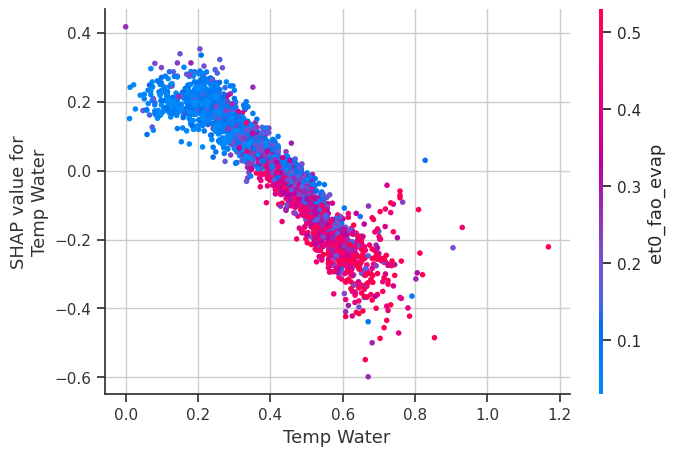

In [22]:
shap.dependence_plot("Temp Water",shap_values,X_testN,feature_names=X_test.columns)

In [23]:
# The SHAP force plot shows you exactly which features had the most influence on the model's prediction for a single observation.
# For a single instance (e.g., index 0)
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], X_testN[0, :], feature_names=X_test.columns)

In [24]:
#shap.force_plot(explainer.expected_value, shap_values, X_testN, feature_names=X_test.columns)

In [25]:
X_testN_df = pd.DataFrame(X_testN, columns=X_test.columns)
X_trainN_df = pd.DataFrame(X_trainN, columns=X_train.columns)
explainer = shap.Explainer(xgboost, X_trainN)
shap_values = explainer(X_testN_df)

 95%|=================== | 2985/3146 [00:19<00:01]       

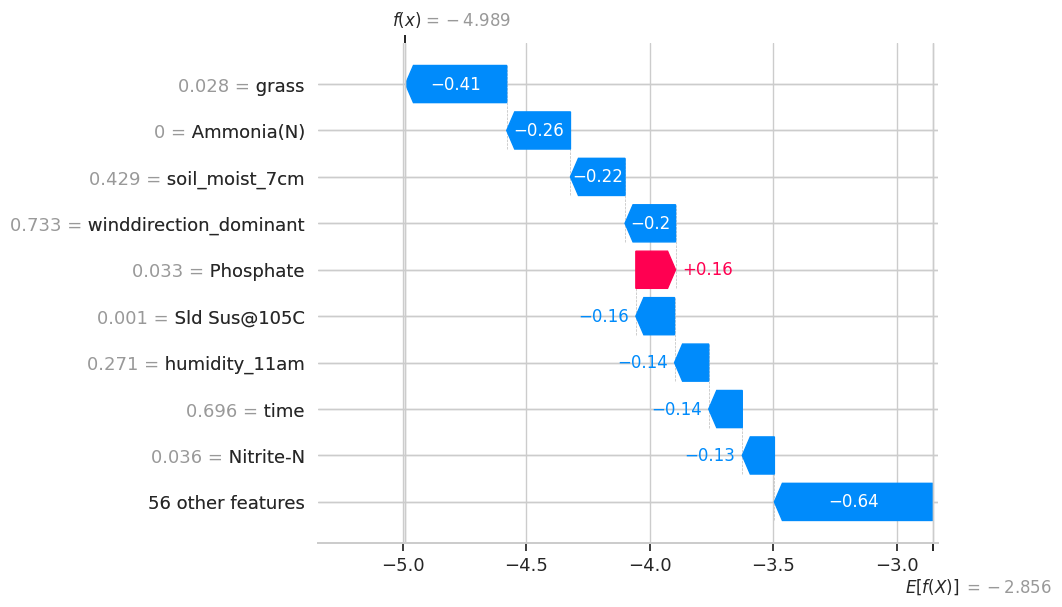

In [26]:
# Visualizes how each feature contributes to the final prediction for a sample:
shap.plots.waterfall(shap_values[0]) 

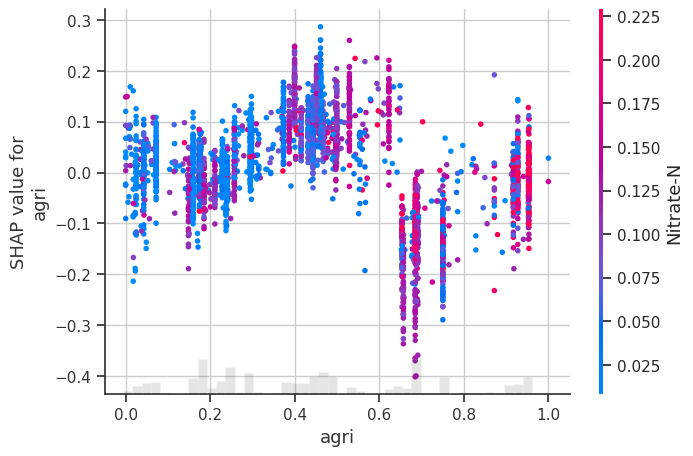

In [27]:
# To show a feature’s SHAP values interacting with another feature
shap.plots.scatter(shap_values[:, "agri"],color=shap_values[:, "Nitrate-N"])

# Histogram on Error

## Generate Abs of Error data for the histogram

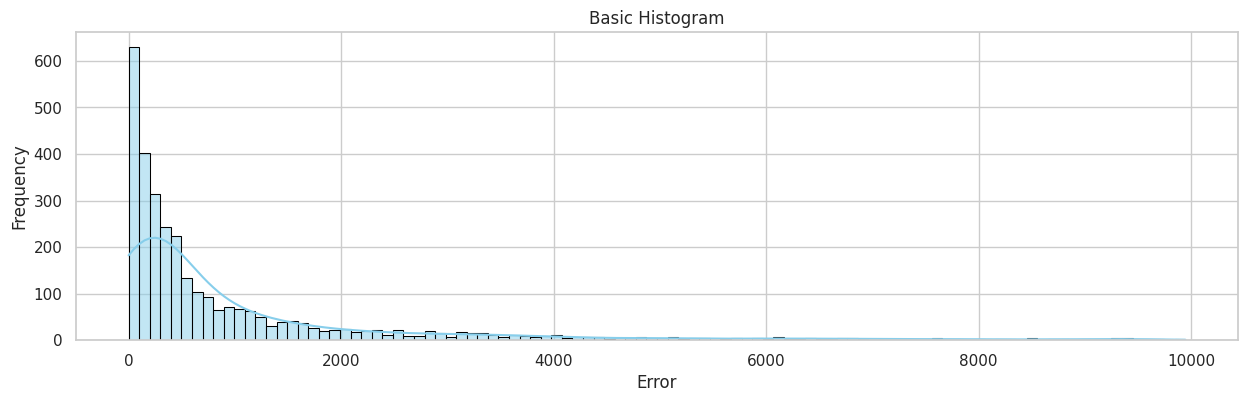

In [28]:
# Generate Abs of Error data for the histogram
abs_erorr = np.abs(y_test1-y_pre[:,0])
 
# Plotting a histogram
plt.figure(figsize=(15, 4))
sns.histplot(abs_erorr, bins=100, kde=True, color='skyblue', edgecolor='black')
 
# Adding labels and title
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.title('Basic Histogram')
 
# Display the plot
plt.show()

## Histogram on the Mean of Error

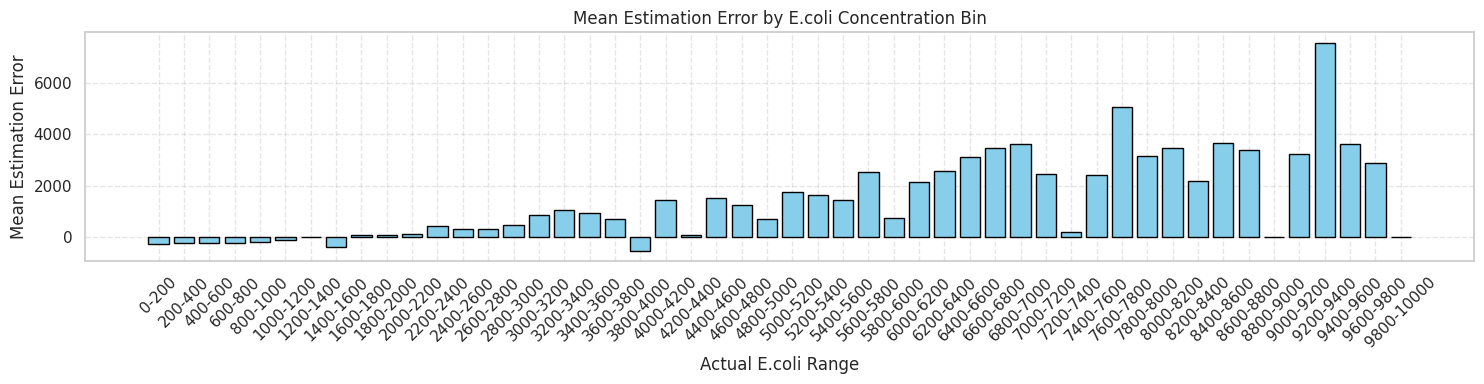

In [29]:
# Define signal strength bins 
bins = np.arange(0, 10200, 200)  

erorr = y_test1-y_pre[:,0]
 

# Digitize signal strength into bin indices
bin_indices = np.digitize(y_test1, bins)

# Compute mean error for each bin
mean_errors = []
bin_labels = []

for i in range(1, len(bins)):
    in_bin = bin_indices == i
    if np.any(in_bin):
        mean_error = np.mean(erorr[in_bin])
        mean_errors.append(mean_error)
        bin_labels.append(f"{bins[i-1]}-{bins[i]}")
    else:
        mean_errors.append(0)
        bin_labels.append(f"{bins[i-1]}-{bins[i]}")

# Plotting
plt.figure(figsize=(15, 4))
plt.bar(bin_labels, mean_errors, color='skyblue', edgecolor='black')
plt.xticks(rotation=45)
plt.xlabel('Actual E.coli Range')
plt.ylabel('Mean Estimation Error')
plt.title('Mean Estimation Error by E.coli Concentration Bin')
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Histogram on the Abd. Mean of Error

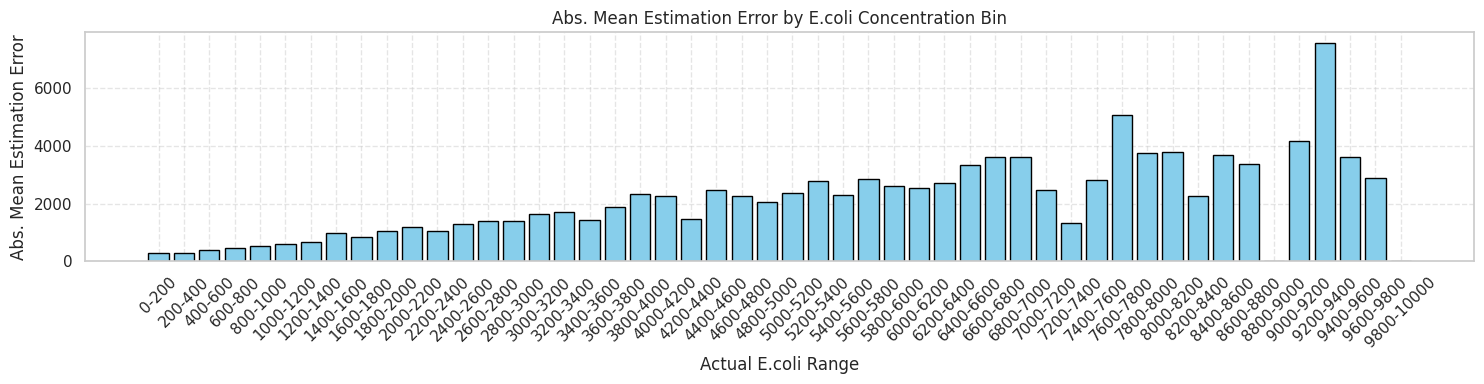

In [30]:
# Define signal strength bins 
bins = np.arange(0, 10200, 200)  

# Digitize signal strength into bin indices
bin_indices = np.digitize(y_test1, bins)

# Compute mean error for each bin
mean_errors = []
bin_labels = []

for i in range(1, len(bins)):
    in_bin = bin_indices == i
    if np.any(in_bin):
        mean_error = np.mean(abs_erorr[in_bin])
        mean_errors.append(mean_error)
        bin_labels.append(f"{bins[i-1]}-{bins[i]}")
    else:
        mean_errors.append(0)
        bin_labels.append(f"{bins[i-1]}-{bins[i]}")

# Plotting
plt.figure(figsize=(15, 4))
plt.bar(bin_labels, mean_errors, color='skyblue', edgecolor='black')
plt.xticks(rotation=45)
plt.xlabel('Actual E.coli Range')
plt.ylabel('Abs. Mean Estimation Error')
plt.title('Abs. Mean Estimation Error by E.coli Concentration Bin')
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Generate the distribution data in histogram format

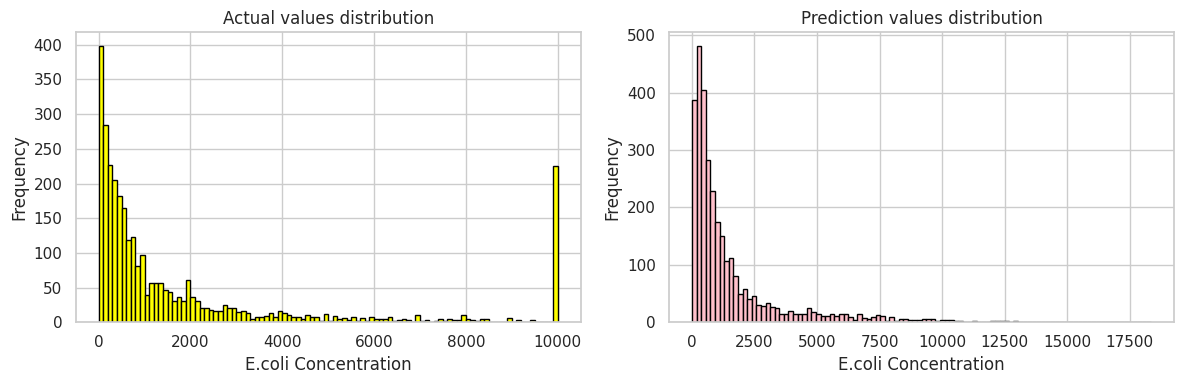

In [31]:
# Generate the distribution data in histogram format
pre = y_pre[:,0]
# Plotting a histogram
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
 
axes[0].hist(y_test1, bins=100, color='Yellow', edgecolor='black')
axes[0].set_title('Actual values distribution')
 
axes[1].hist(pre, bins=100, color='Pink', edgecolor='black')
axes[1].set_title('Prediction values distribution')
 
# Adding labels and title
for ax in axes:
    ax.set_xlabel('E.coli Concentration')
    ax.set_ylabel('Frequency')
    
# Adjusting layout for better spacing
plt.tight_layout()
 
# Display the figure
plt.show()

# Precision-Recall and ROC curves 

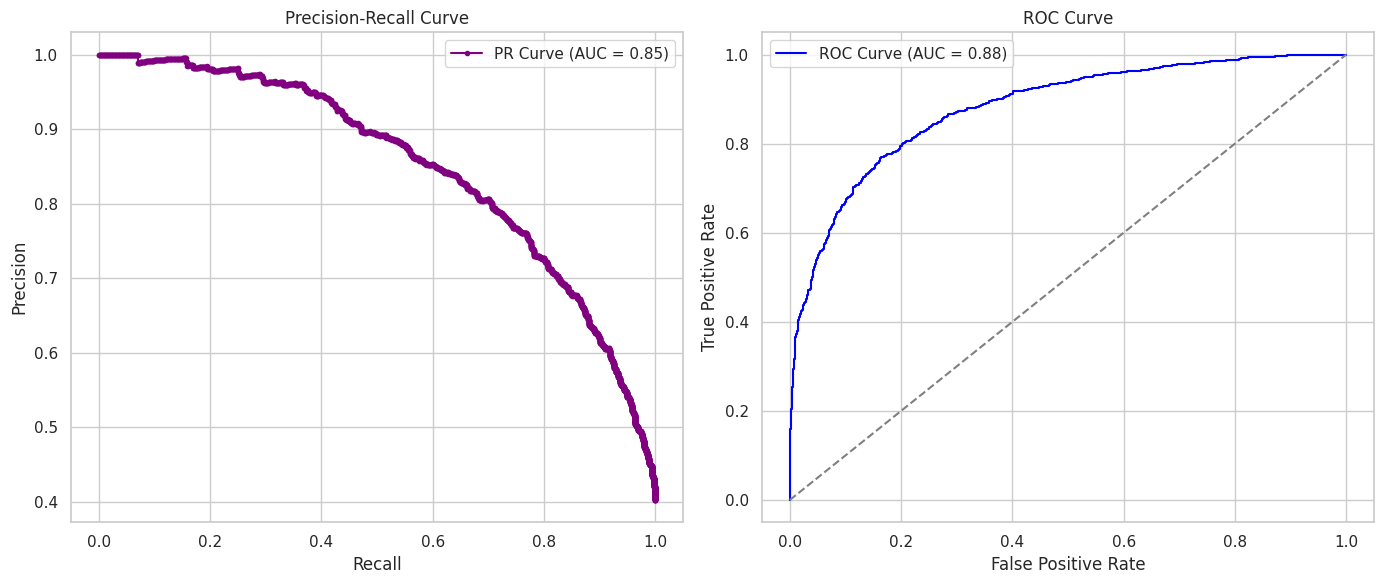

In [32]:
# Define a threshold to create binary classification labels
# y_true > 1000 as the positive class for E.coli
binary_true = (y_test > 1000).astype(int)

# Precision-Recall Curve
precision_xgr, recall_xgr, pr_thresholds_xgr = precision_recall_curve(binary_true, y_pre.reshape(-1))
pr_auc_xgr = auc(recall_xgr, precision_xgr)

# ROC Curve
fpr_xgr, tpr_xgr, roc_thresholds_xgr = roc_curve(binary_true, Scaler1.inverse_transform(y_pre.reshape(-1, 1)).reshape(-1))
roc_auc_xgr = auc(fpr_xgr, tpr_xgr)

# 4. Plotting
plt.figure(figsize=(14, 6))

# Precision-Recall Curve
plt.subplot(1, 2, 1)
plt.plot(recall_xgr, precision_xgr, label=f'PR Curve (AUC = {pr_auc_xgr:.2f})', marker='.', color='purple')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

# ROC Curve
plt.subplot(1, 2, 2)
plt.plot(fpr_xgr, tpr_xgr, color='blue', label=f'ROC Curve (AUC = {roc_auc_xgr:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Other acuuracy metrics

three other Accuracy metrics. 

In [33]:
tst = y_test.to_numpy().copy()
pre = y_pre.reshape(-1).copy()
tst[tst<10] = 10
tst[tst>10000] = 10000
pre[pre<10] = 10
pre[pre>10000] = 10000

# Accuracy = (1 - sMAPE) * 100
print("Accuracy = (1 - sMAPE) * 100 = %.5f" % (( np.mean(np.abs(tst - pre) / ((np.abs(tst)+np.abs(pre))/2))) * 100),"%")

# Percentage of estimations within a certain error margin.
# Accuracy = (number of estimations with error < thr)/ all samples
thr = 0.4
tst = np.log10(tst)
pre = np.log10(pre)
error = (np.abs(pre - tst))
print("Accuracy = number of estimations with error < 0.4)/ all samples = %.5f" % ((error < thr).sum()/len(error)*100),"%")

# threshold based accuracy. precentage of estimation with error < thr of actual value
thr = 0.05
error = np.abs(pre - tst) < 0.2 * tst
print("Accuracy = precentage of estimation with error < 20 percent of actual value = %.5f" % (error.sum()/len(tst)*100),"%")

Accuracy = (1 - sMAPE) * 100 = 65.76648 %
Accuracy = number of estimations with error < 0.4)/ all samples = 69.29434 %
Accuracy = precentage of estimation with error < 20 percent of actual value = 80.22886 %


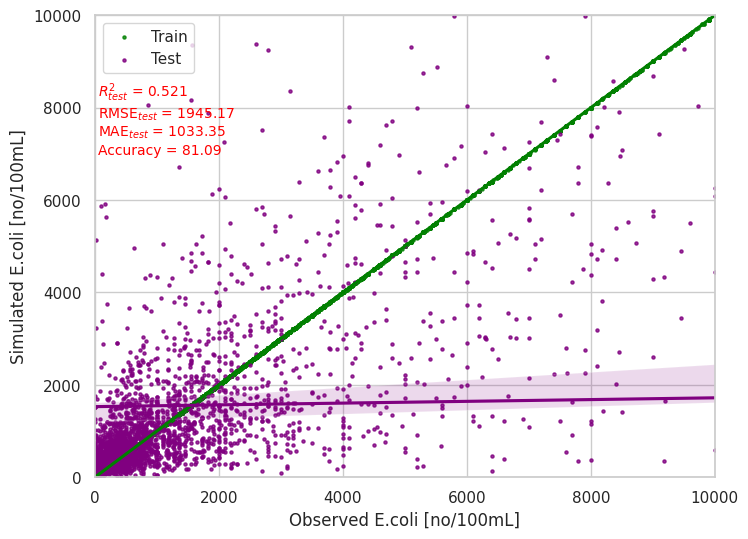

In [35]:
# Calculating metrics
r2_train = r2_score(Scaler1.inverse_transform(y_trainN).reshape(-1, 1),
                                                        Scaler1.inverse_transform(y_pre_tr.reshape(-1, 1)))
r2_test = r2_score(y_test1, y_pre)
mae_test = mean_absolute_error(y_test1, y_pre)
rmse_train = np.sqrt(mean_squared_error(Scaler1.inverse_transform(y_trainN).reshape(-1, 1),
                                                        Scaler1.inverse_transform(y_pre_tr.reshape(-1, 1))))
rmse_test = np.sqrt(mean_squared_error(y_test1, y_pre))

# Creating the plot
plt.figure(figsize=(8, 6))

# Plot train data
sns.regplot(x=y_train, y=Scaler1.inverse_transform(y_trainN).reshape(-1, 1), scatter_kws={'color':'green', 's':5}, line_kws={'color':'green'}, label='Train')

# Plot test data
sns.regplot(x=y_test, y=y_pre, scatter_kws={'color':'purple', 's':5}, line_kws={'color':'purple'}, label='Test')

# Adding text with metrics
plt.text(50, 7000, f'$R^2_{{test}}$ = {r2_test:.3f}\nRMSE$_{{test}}$ = {rmse_test:.2f}\nMAE$_{{test}}$ = {mae_test:.2f}\nAccuracy = {Accuarcy*100:.2f}', fontsize=10, color='Red')

# Labels and Title
plt.xlabel('Observed E.coli [no/100mL]')
plt.ylabel('Simulated E.coli [no/100mL]')
plt.xlim(0, 10000)
plt.ylim(0, 10000)
#plt.title('Extreme Gradient Boosting')

plt.legend()
plt.show()

## LGBM model for E.coli Estimator

LightGBM (Light Gradient Boosting Machine) is another gradient boosting framework optimized for speed and performance on large datasets.

In [36]:
# LGBM model for E.coli Estimator
# Evaluate with the above cell 3 cells
import lightgbm as lgb
hyper_params = {
    'boosting_type': 'gbdt',
    'objective': 'regression',
    'metric': ['l1','l2'],
    'learning_rate': 0.02, #0.005
    'feature_fraction': 0.7,
    #'bagging_fraction': 0.7,
    #'bagging_freq': 10,
    'verbose': 0,
    "max_depth": -1,
    "num_leaves": 15,  # 31
    #"max_bin": 512,.
    "num_iterations": 550} # 2550
gbm = lgb.LGBMRegressor(**hyper_params)
gbm.fit(X_trainN, y_trainN
        #eval_set=[(X_testN, y_testN)],
        #eval_metric='l1',
        #callbacks=[lgb.early_stopping(stopping_rounds=10),]
       )
y_pre_tr = gbm.predict(X_trainN
                       #num_iteration=gbm.best_iteration_
                      )
#print('Train RMSE:{}'.format(np.sqrt(mean_squared_error(y_train, y_pre_tr))))
print('Train RMSE:{}'.format(np.sqrt(mean_squared_error(Scaler1.inverse_transform(y_trainN).reshape(-1, 1),
                                                        Scaler1.inverse_transform(y_pre_tr.reshape(-1, 1))))))
y_pre = gbm.predict(X_testN)
y_pre = Scaler1.inverse_transform(y_pre.reshape(-1, 1))
y_pre[y_pre<0] = 0 # replace negative prediction with zero

print('Test RMSE:{}'.format(np.sqrt(mean_squared_error(y_test.to_numpy(),
                                                        y_pre))))

[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
Train RMSE:1687.2391917097445
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
Test RMSE:28210.68607412175


col_0,low,moderate,high
row_0,,,
high,0.224409,0.478105,0.885375
moderate,0.627297,0.502234,0.114625
low,0.148294,0.019660,0.000000


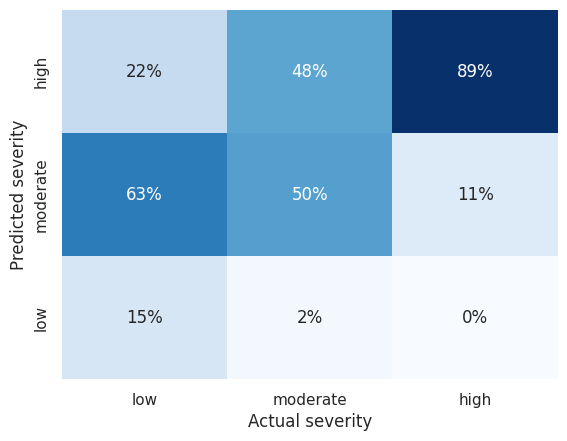

In [37]:
# three classes (x<235, 235<x<1000, 1000<x)
yt_severity = y_test.astype(float).apply(lambda x: ("low" if (x <235)
                                                    else("moderate" if  (1000>=x>=235)
                                                         else "high")))
yp_severity = pd.DataFrame({'ecoli': y_pre.reshape(-1)})['ecoli'].astype(float).apply(lambda x: ("low" if (x <235)
                                                    else("moderate" if  (1000>=x>=235)
                                                         else "high")))

to_plot = pd.crosstab(yp_severity.to_numpy(), yt_severity.to_numpy())
SEVERITY_LEFT_EDGES = {"low": 1, "moderate": 2, "high": 3}
SEVERITY_LEVEL_NAMES = list(SEVERITY_LEFT_EDGES.keys())

# make sure crosstab is even on both axes
for level in SEVERITY_LEVEL_NAMES:
    if level not in to_plot.index:
        to_plot.loc[level, :] = 0
    if level not in to_plot.columns:
        to_plot[level] = 0

# reverse index order for plotting
to_plot = to_plot.loc[SEVERITY_LEVEL_NAMES[::-1], SEVERITY_LEVEL_NAMES]
fmt = ",.0f"

normalize = True
if normalize:
    to_plot = to_plot / to_plot.sum()
    fmt = ".0%"

sns.heatmap(to_plot, cmap="Blues", annot=True, fmt=fmt, cbar=False)
plt.xlabel("Actual severity")
plt.ylabel("Predicted severity")
to_plot

col_0         low-moderate  high
row_0                           
high                   674  1152
low-moderate          1163   157
Performance accuracy: 0.73586


Text(46.24999999999999, 0.5, 'Predicted severity')

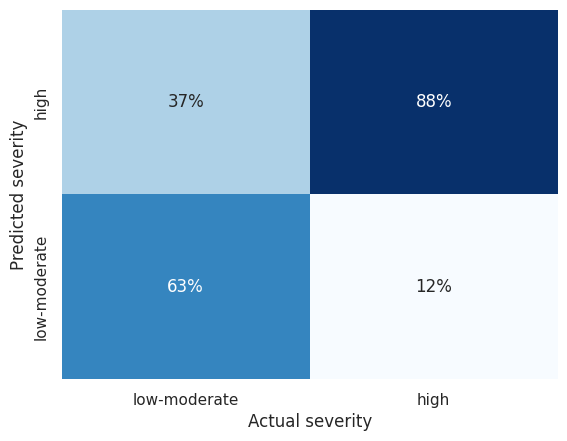

In [38]:
# two classes (x<thr, thr<x)
# U can change the threshold by choosing "thr" value
thr = 1000
yt_severity = y_test.astype(float).apply(lambda x: ("low-moderate" if (x <thr)
                                                         else "high"))
yp_severity = pd.DataFrame({'ecoli': y_pre.reshape(-1)})['ecoli'].astype(float).apply(
    lambda x: ("low-moderate" if (x <thr) else "high"))

to_plot = pd.crosstab(yp_severity.to_numpy(), yt_severity.to_numpy())
SEVERITY_LEFT_EDGES = {"low-moderate": 1, "high": 2}
SEVERITY_LEVEL_NAMES = list(SEVERITY_LEFT_EDGES.keys())

# make sure crosstab is even on both axes
for level in SEVERITY_LEVEL_NAMES:
    if level not in to_plot.index:
        to_plot.loc[level, :] = 0
    if level not in to_plot.columns:
        to_plot[level] = 0

# reverse index order for plotting
to_plot = to_plot.loc[SEVERITY_LEVEL_NAMES[::-1], SEVERITY_LEVEL_NAMES]
fmt = ",.0f"
print(to_plot)
print("Performance accuracy: %.5f" % ((to_plot['high']['high'] + to_plot['low-moderate']['low-moderate'])/y_test.size))
Accuarcy = ((to_plot['high']['high'] + to_plot['low-moderate']['low-moderate'])/y_test.size)

normalize = True
if normalize:
    to_plot = to_plot / to_plot.sum()#.sum()
    fmt = ".0%"

sns.heatmap(to_plot, cmap="Blues", annot=True, fmt=fmt, cbar=False)
plt.xlabel("Actual severity")
plt.ylabel("Predicted severity")

## LinearRegression model for E.coli Estimator

A simple statistical model that predicts E. coli levels based on a weighted sum of input features. It serves as a baseline comparison for more complex models. It capable of provide suitable performance when there are strong linear correlation, but in the case of estimation of E.coli is failed.

Test RMSE:28491.792953931257


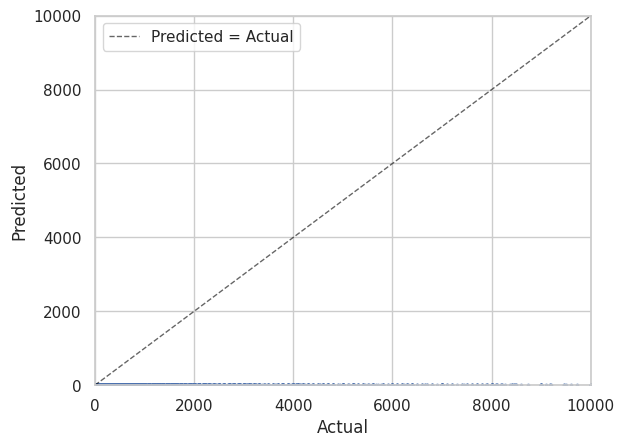

In [39]:
# LinearRegression model for E.coli Estimator
Linear_reg = LinearRegression()
Linear_reg.fit(X_trainN, y_trainN)
y_pre = Linear_reg.predict(X_testN)
print('Test RMSE:{}'.format(np.sqrt(mean_squared_error(y_test.to_numpy(),
                                                        Scaler1.inverse_transform(y_pre.reshape(-1, 1))))))
plt.scatter(x=y_test.to_numpy(), y=y_pre, s=3, alpha=0.8)
plt.axline((0, 0),(10000, 10000),color="black",linestyle="--",alpha=0.6,linewidth=1,label="Predicted = Actual",)
plt.xlim(0, 10000)
plt.ylim(0, 10000)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()

## MLP model for E.coli Estimator

A Multi-Layer Perceptron (MLP) is a type of neural network used for regression. It consists of 3 layers of neurons and can capture complex relationships in the data.

In [40]:
# MLP model for E.coli Estimator
historymlp = History()
model3 = Sequential()
model3.add(Dense(25, activation='relu'))
model3.add(Dense(10, activation='relu'))
model3.add(Dense(1, activation='linear'))
opt = keras.optimizers.RMSprop(learning_rate=0.002)
model3.compile(loss='mse', optimizer=opt)
#model3.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
model3.fit(X_trainN, (y_trainN), epochs=100, batch_size=16, validation_split=0.2, verbose=1, shuffle=True, 
          callbacks = [historymlp, keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=5, verbose=0, mode='auto')])

2025-08-05 07:45:15.795953: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/100
892/892 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0780 - val_loss: 0.0669
Epoch 2/100
892/892 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0633 - val_loss: 0.0655
Epoch 3/100
892/892 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0569 - val_loss: 0.0629
Epoch 4/100
892/892 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0562 - val_loss: 0.0568
Epoch 5/100
892/892 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0550 - val_loss: 0.0663
Epoch 6/100
892/892 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0538 - val_loss: 0.0634
Epoch 7/100
892/892 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0513 - val_loss: 0.0550
Epoch 8/100
892/892 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0552 - val_loss: 0.0562
Epoch 9/100
892/892 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0490 - val_loss: 0.0825
Epoch 10/100
892/892 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0504 - val_loss: 0.0574
Epoch 11/100
892/892 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0524 - val_loss: 0.0544
Epoch 12/100
892/892 ━━━━━━━━━━━━━━━━━━━━

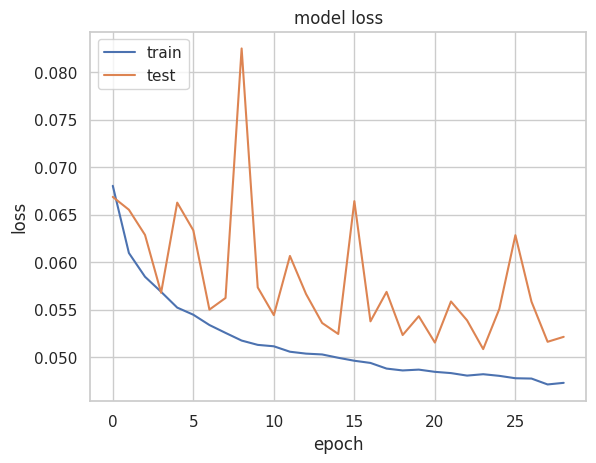

In [41]:
plt.plot(historymlp.history['loss'])
plt.plot(historymlp.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test RMSE:28354.79963950101


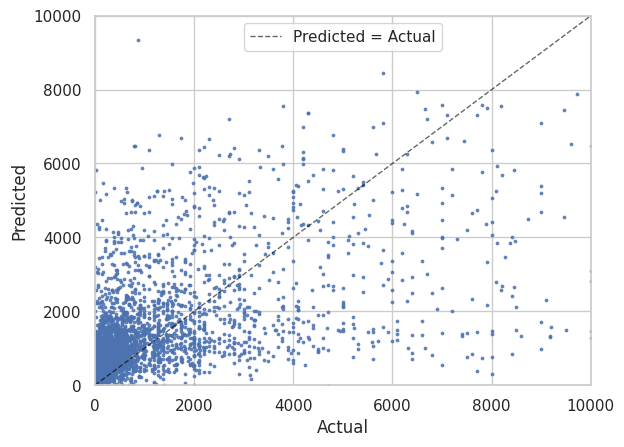

In [42]:
y_pre_testmlp = model3.predict(X_testN)
print('Test RMSE:{}'.format(np.sqrt(mean_squared_error(y_test, Scaler1.inverse_transform(y_pre_testmlp.reshape(-1, 1))))))
plt.scatter(x=y_test.to_numpy(), y=Scaler1.inverse_transform(y_pre_testmlp.reshape(-1, 1)), s=3, alpha=0.8)
plt.axline((0, 0),(10000, 10000),color="black",linestyle="--",alpha=0.6,linewidth=1,label="Predicted = Actual",)
plt.xlim(0, 10000)
plt.ylim(0, 10000)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()

col_0         low-moderate  high
row_0                           
high                   794  1072
low-moderate          1043   237
Performance accuracy: 0.67228


Text(46.24999999999999, 0.5, 'Predicted severity')

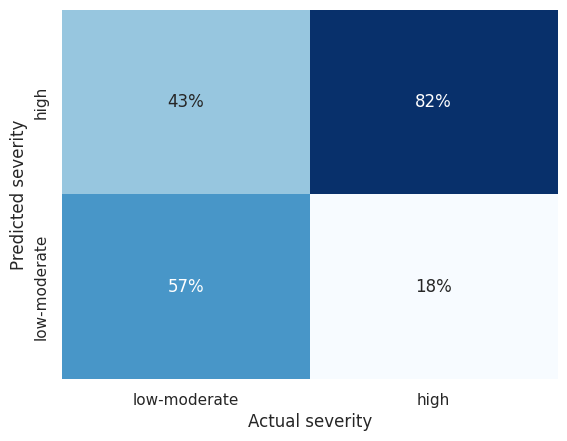

In [43]:
thr = 1000
yt_severity = y_test.astype(float).apply(lambda x: ("low-moderate" if (x <thr)
                                                         else "high"))
yp_severity = pd.DataFrame({'ecoli': Scaler1.inverse_transform(y_pre_testmlp.reshape(-1, 1)).reshape(-1)})['ecoli'].astype(float).apply(lambda x: ("low-moderate" if (x <thr)
                                                         else "high"))

to_plot = pd.crosstab(yp_severity.to_numpy(), yt_severity.to_numpy())
SEVERITY_LEFT_EDGES = {"low-moderate": 1, "high": 2}
SEVERITY_LEVEL_NAMES = list(SEVERITY_LEFT_EDGES.keys())

# make sure crosstab is even on both axes
for level in SEVERITY_LEVEL_NAMES:
    if level not in to_plot.index:
        to_plot.loc[level, :] = 0
    if level not in to_plot.columns:
        to_plot[level] = 0

        
# reverse index order for plotting
to_plot = to_plot.loc[SEVERITY_LEVEL_NAMES[::-1], SEVERITY_LEVEL_NAMES]
fmt = ",.0f"
print(to_plot)
print("Performance accuracy: %.5f" % ((to_plot['high']['high'] + to_plot['low-moderate']['low-moderate'])/y_test.size))


normalize = True
if normalize:
    to_plot = to_plot / to_plot.sum()
    fmt = ".0%"

sns.heatmap(to_plot, cmap="Blues", annot=True, fmt=fmt, cbar=False)
plt.xlabel("Actual severity")
plt.ylabel("Predicted severity")


## XGBRegressor model for E.coli Estimator with cross validation

This extends the XGBoost model with cross-validation (CV), ensuring that the model's performance is evaluated across multiple subsets of the data to avoid overfitting. 

In [44]:
# XGBRegressor model for E.coli Estimator with cross validation
#skf = StratifiedKFold(n_splits=5, random_state=40, shuffle=True)
skf = sklearn.model_selection.KFold(n_splits=10, shuffle=True, random_state=40) # to shuffle
#skf = sklearn.model_selection.KFold(n_splits=10, shuffle=False)
# Parameter dictionary specifying base learner 
param = { "objective":"reg:tweedie"} # ,"subsample": 0.9
trained_models = []
scores = []
for i, (train_idx, valid_idx) in enumerate(skf.split(X_train.to_numpy(), pd.DataFrame({'E.coli C-MF': y_train}))):
#for train_idx, valid_idx in skf.split(y_train.to_numpy(), y_train.to_numpy()):
    
    # Train model on fold
    train_split_features = X_train.iloc[train_idx]
    valid_split_features = X_train.iloc[valid_idx]
    train_label_features = pd.DataFrame({'E.coli C-MF': y_train}).iloc[train_idx]
    valid_label_features = pd.DataFrame({'E.coli C-MF': y_train}).iloc[valid_idx]
    
    train_dmatrix = xg.DMatrix(data = train_split_features, label = train_label_features) 
    valid_dmatrix = xg.DMatrix(data = valid_split_features, label = valid_label_features) 
    
    eval_set = [(valid_dmatrix,'eval'), (train_dmatrix,'train')] 
    
    #model.fit(X_train, y_train, eval_metric="error", eval_set=eval_set, verbose=True)

    trained_model = xg.train(params = param, dtrain = train_dmatrix, num_boost_round = 200, evals=eval_set, early_stopping_rounds=20) 
    
    trained_models.append(trained_model)   
    # save model
    #joblib.dump(trained_model, f'Model/xgbr_f{i}_Tmp_adv.joblib')
    
    pred = trained_model.predict(valid_dmatrix) 
    scores.append(np.sqrt(mean_squared_error(pd.DataFrame({'E.coli C-MF': y_train}).iloc[valid_idx],pred)))
    
# RMSE Computation 
print('Validation RMSE:{}'.format(sum(scores) / len(scores)))

[0]	eval-tweedie-nloglik@1.5:1036.57555	train-tweedie-nloglik@1.5:1007.90383
[1]	eval-tweedie-nloglik@1.5:776.24930	train-tweedie-nloglik@1.5:754.21258
[2]	eval-tweedie-nloglik@1.5:585.48612	train-tweedie-nloglik@1.5:568.69247
[3]	eval-tweedie-nloglik@1.5:447.31716	train-tweedie-nloglik@1.5:434.27114
[4]	eval-tweedie-nloglik@1.5:349.29584	train-tweedie-nloglik@1.5:338.28076
[5]	eval-tweedie-nloglik@1.5:280.53481	train-tweedie-nloglik@1.5:271.21983
[6]	eval-tweedie-nloglik@1.5:234.36964	train-tweedie-nloglik@1.5:225.66423
[7]	eval-tweedie-nloglik@1.5:203.96792	train-tweedie-nloglik@1.5:195.88865
[8]	eval-tweedie-nloglik@1.5:184.77263	train-tweedie-nloglik@1.5:177.10638
[9]	eval-tweedie-nloglik@1.5:172.93691	train-tweedie-nloglik@1.5:165.71828
[10]	eval-tweedie-nloglik@1.5:166.20901	train-tweedie-nloglik@1.5:158.88579
[11]	eval-tweedie-nloglik@1.5:162.11406	train-tweedie-nloglik@1.5:154.94684
[12]	eval-tweedie-nloglik@1.5:159.90745	train-tweedie-nloglik@1.5:152.46764
[13]	eval-tweedie-nl

In [45]:
preds = []
test_dmatrix = xg.DMatrix(data = X_test, label = y_test) 
for model in trained_models:
    preds.append(pd.Series(data=model.predict(test_dmatrix), dtype='float64'))
preds = pd.concat(preds, axis=1)
preds = preds.mean(axis=1)
preds[preds<0] = 0 # replace negative prediction with zero

# to calculate RMSE we need to also down scale the test samples as well
a = np.array(y_test.values)
y_test1 = np.where(a > 10000, 10000, a) 

# RMSE Computation 
print('Test RMSE:{}'.format(np.sqrt(mean_squared_error(y_test1,preds))))

Test RMSE:1870.5235561384147


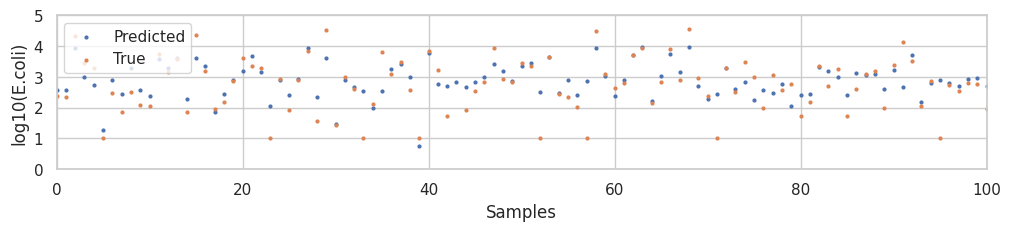

In [46]:
plt.figure(figsize=(12,2))
plt.scatter(preds.index,np.log10(preds.to_numpy()), label='Predicted', s=4)
plt.scatter(preds.index,np.log10(y_test.to_numpy()),label="True", s=4)            
plt.ylabel("log10(E.coli)")
plt.xlabel("Samples")
plt.legend(loc='upper left')
plt.ylim(0,5)
plt.xlim(0,100)
plt.show()

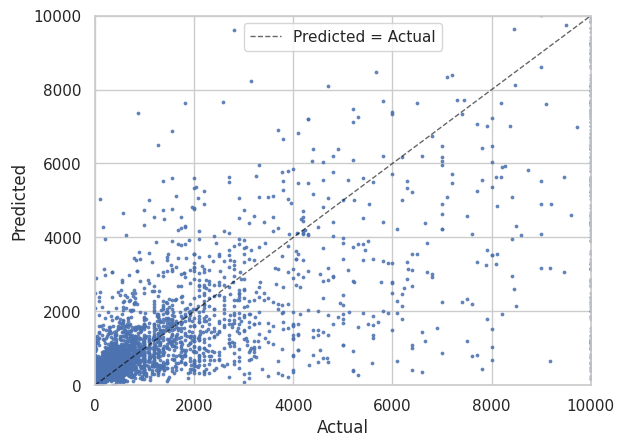

In [47]:
plt.scatter(x=y_test1, y=preds, s=3, alpha=0.8)
plt.axline((0, 0),(10000, 10000),color="black",linestyle="--",alpha=0.6,linewidth=1,label="Predicted = Actual",)
plt.xlim(0, 10000)
plt.ylim(0, 10000)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()

col_0,low,moderate,high
row_0,,,
high,0.056430,0.237712,0.786561
moderate,0.481627,0.697945,0.205534
low,0.461942,0.064343,0.007905


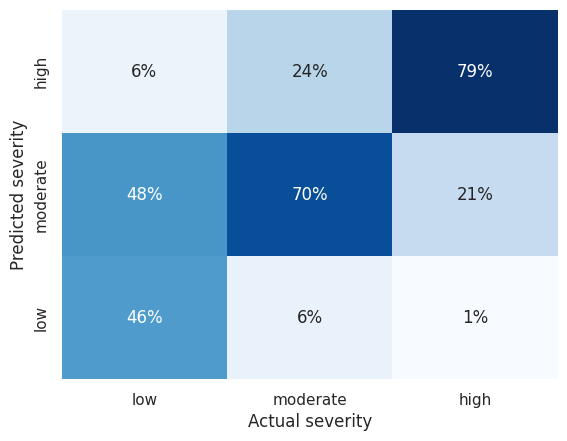

In [48]:
# three classes (x<235, 235<x<1000, 1000<x)
yt_severity = y_test.astype(float).apply(lambda x: ("low" if (x <235)
                                                    else("moderate" if  (1000>=x>=235)
                                                         else "high")))
yp_severity = pd.DataFrame({'ecoli': preds})['ecoli'].astype(float).apply(lambda x: ("low" if (x <235)
                                                    else("moderate" if  (1000>=x>=235)
                                                         else "high")))

to_plot = pd.crosstab(yp_severity.to_numpy(), yt_severity.to_numpy())
SEVERITY_LEFT_EDGES = {"low": 1, "moderate": 2, "high": 3}
SEVERITY_LEVEL_NAMES = list(SEVERITY_LEFT_EDGES.keys())

# make sure crosstab is even on both axes
for level in SEVERITY_LEVEL_NAMES:
    if level not in to_plot.index:
        to_plot.loc[level, :] = 0
    if level not in to_plot.columns:
        to_plot[level] = 0

# reverse index order for plotting
to_plot = to_plot.loc[SEVERITY_LEVEL_NAMES[::-1], SEVERITY_LEVEL_NAMES]
fmt = ",.0f"

normalize = True
if normalize:
    to_plot = to_plot / to_plot.sum()
    fmt = ".0%"

sns.heatmap(to_plot, cmap="Blues", annot=True, fmt=fmt, cbar=False)
plt.xlabel("Actual severity")
plt.ylabel("Predicted severity")
to_plot

Performance accuracy: 0.81723
col_0         low-moderate  high
row_0                           
high                   285  1019
low-moderate          1552   290


Text(46.24999999999999, 0.5, 'Predicted severity')

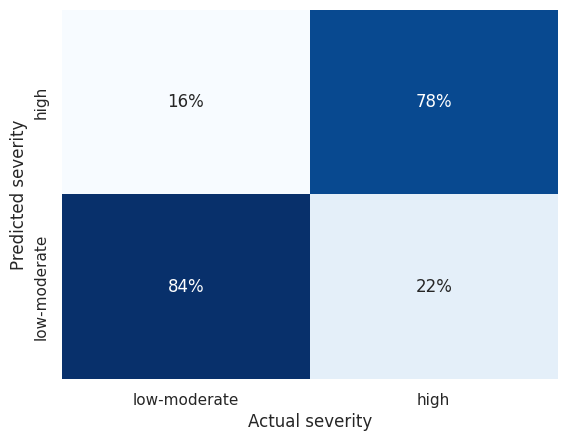

In [49]:
thr = 1000
yt_severity = y_test.astype(float).apply(lambda x: ("low-moderate" if (x <thr)
                                                         else "high"))
yp_severity = pd.DataFrame({'ecoli': preds})['ecoli'].astype(float).apply(lambda x: ("low-moderate" if (x <thr)
                                                         else "high"))

to_plot = pd.crosstab(yp_severity.to_numpy(), yt_severity.to_numpy())
SEVERITY_LEFT_EDGES = {"low-moderate": 1, "high": 2}
SEVERITY_LEVEL_NAMES = list(SEVERITY_LEFT_EDGES.keys())

# make sure crosstab is even on both axes
for level in SEVERITY_LEVEL_NAMES:
    if level not in to_plot.index:
        to_plot.loc[level, :] = 0
    if level not in to_plot.columns:
        to_plot[level] = 0

# reverse index order for plotting
to_plot = to_plot.loc[SEVERITY_LEVEL_NAMES[::-1], SEVERITY_LEVEL_NAMES]
fmt = ",.0f"
Accuracy = ((to_plot['high']['high'] + to_plot['low-moderate']['low-moderate'])/y_test.size)
print("Performance accuracy: %.5f" % Accuracy)
print(to_plot)
normalize = True
if normalize:
    to_plot = to_plot / to_plot.sum()
    fmt = ".0%"

sns.heatmap(to_plot, cmap="Blues", annot=True, fmt=fmt, cbar=False)
plt.xlabel("Actual severity")
plt.ylabel("Predicted severity")

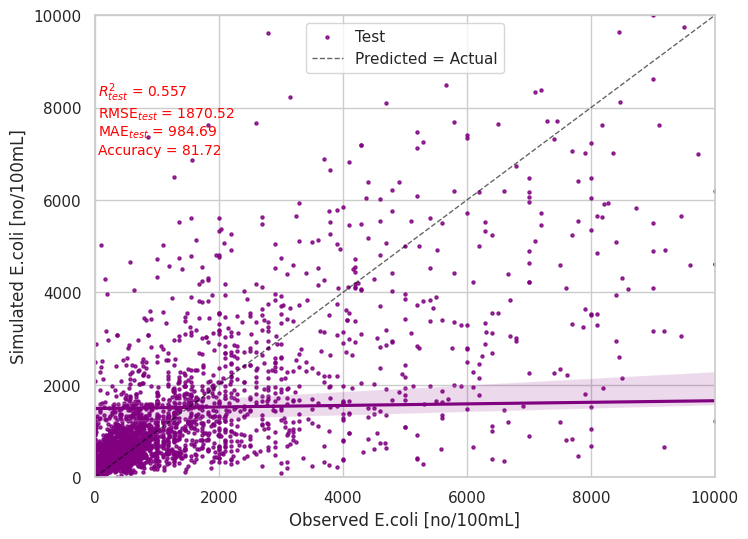

In [50]:
# Calculating metrics
r2_test = r2_score(y_test1, preds)
mae_test = mean_absolute_error(y_test1, preds)
rmse_test = np.sqrt(mean_squared_error(y_test1, preds))

# Creating the plot
plt.figure(figsize=(8, 6))

# Plot test data
sns.regplot(x=y_test, y=preds, scatter_kws={'color':'purple', 's':5}, line_kws={'color':'purple'}, label='Test')

plt.axline((0, 0),(10000, 10000),color="black",linestyle="--",alpha=0.6,linewidth=1,label="Predicted = Actual",)

# Adding text with metrics
plt.text(50, 7000, f'$R^2_{{test}}$ = {r2_test:.3f}\nRMSE$_{{test}}$ = {rmse_test:.2f}\nMAE$_{{test}}$ = {mae_test:.2f}\nAccuracy = {Accuracy*100:.2f}', fontsize=10, color='Red')

# Labels and Title
plt.xlabel('Observed E.coli [no/100mL]')
plt.ylabel('Simulated E.coli [no/100mL]')
plt.xlim(0, 10000)
plt.ylim(0, 10000)
#plt.title('Extreme Gradient Boosting')

plt.legend()
plt.show()

## Generate Abs of Error data for the histogram

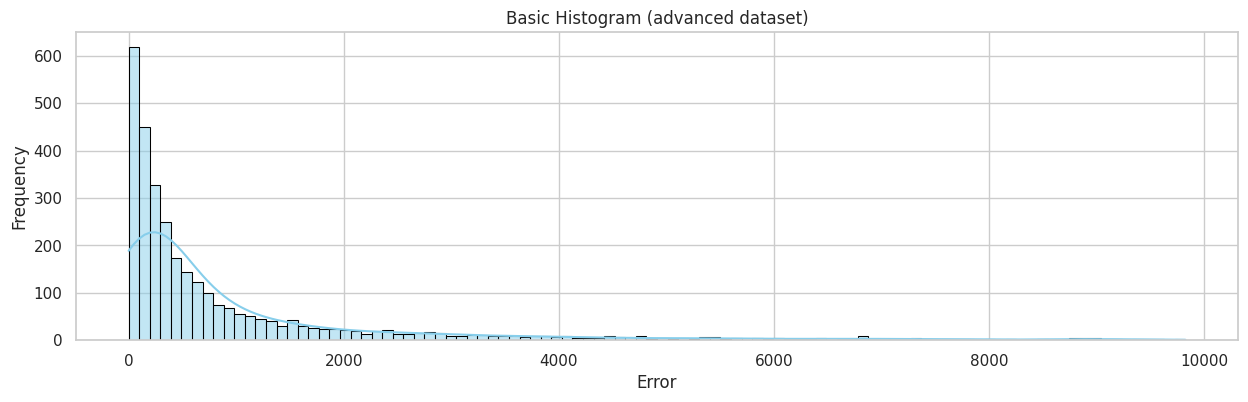

In [51]:
##### Generate Abs of Erorr data for the histogram
abs_erorr = np.abs(y_test1-preds)
 
# Plotting a histogram
plt.figure(figsize=(15, 4))
sns.histplot(abs_erorr, bins=100, kde=True, color='skyblue', edgecolor='black')
 
# Adding labels and title
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.title('Basic Histogram (advanced dataset)')
 
# Display the plot
plt.show()

## Histogram on the Mean of Error

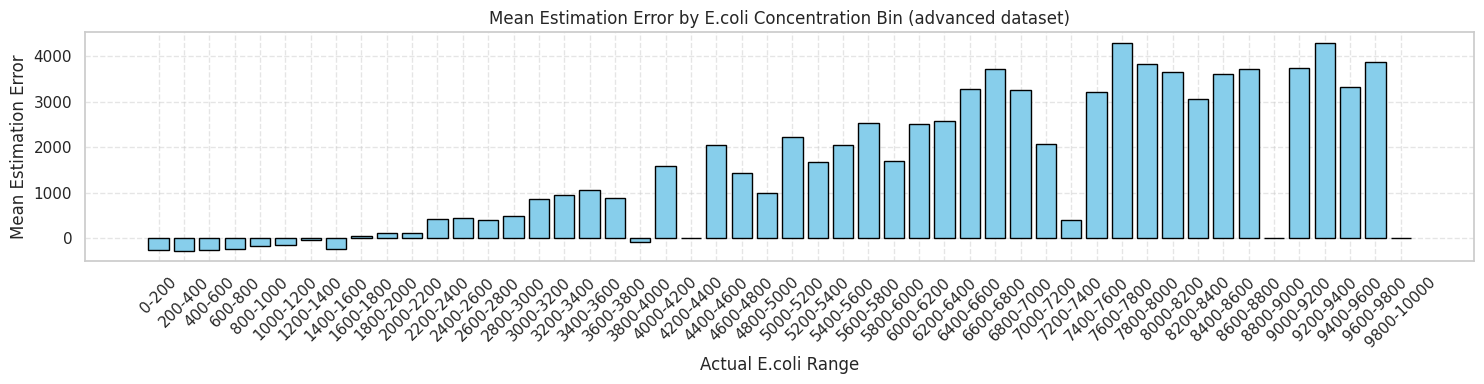

In [52]:
# Define signal strength bins 
bins = np.arange(0, 10200, 200)  

erorr = y_test1-preds
 

# Digitize signal strength into bin indices
bin_indices = np.digitize(y_test1, bins)

# Compute mean error for each bin
mean_errors = []
bin_labels = []

for i in range(1, len(bins)):
    in_bin = bin_indices == i
    if np.any(in_bin):
        mean_error = np.mean(erorr[in_bin])
        mean_errors.append(mean_error)
        bin_labels.append(f"{bins[i-1]}-{bins[i]}")
    else:
        mean_errors.append(0)
        bin_labels.append(f"{bins[i-1]}-{bins[i]}")

# Plotting
plt.figure(figsize=(15, 4))
plt.bar(bin_labels, mean_errors, color='skyblue', edgecolor='black')
plt.xticks(rotation=45)
plt.xlabel('Actual E.coli Range')
plt.ylabel('Mean Estimation Error')
plt.title('Mean Estimation Error by E.coli Concentration Bin (advanced dataset)')
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Histogram on the Abd. Mean of Error

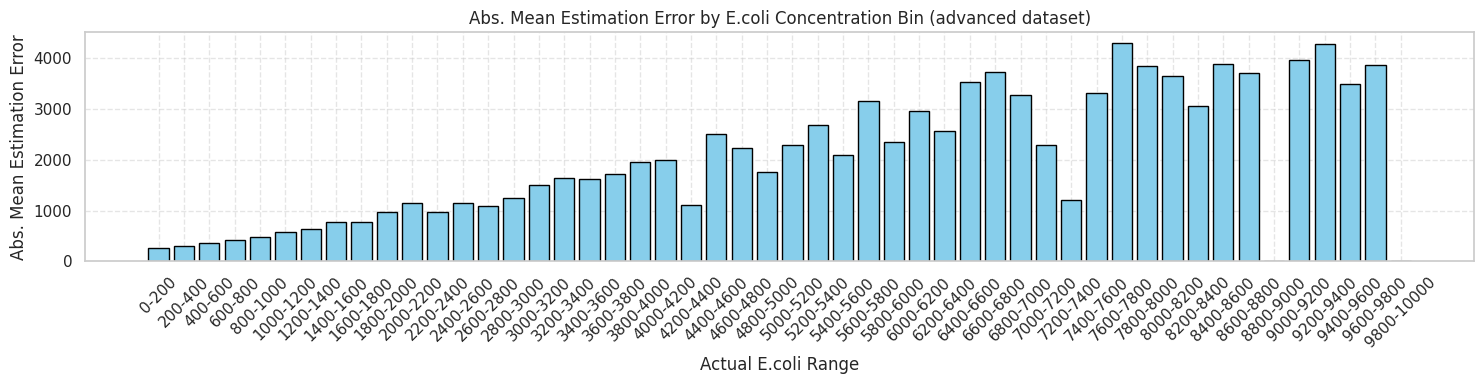

In [53]:
# Define signal strength bins 
bins = np.arange(0, 10200, 200)  

# Digitize signal strength into bin indices
bin_indices = np.digitize(y_test1, bins)

# Compute mean error for each bin
mean_errors = []
bin_labels = []

for i in range(1, len(bins)):
    in_bin = bin_indices == i
    if np.any(in_bin):
        mean_error = np.mean(abs_erorr[in_bin])
        mean_errors.append(mean_error)
        bin_labels.append(f"{bins[i-1]}-{bins[i]}")
    else:
        mean_errors.append(0)
        bin_labels.append(f"{bins[i-1]}-{bins[i]}")

# Plotting
plt.figure(figsize=(15, 4))
plt.bar(bin_labels, mean_errors, color='skyblue', edgecolor='black')
plt.xticks(rotation=45)
plt.xlabel('Actual E.coli Range')
plt.ylabel('Abs. Mean Estimation Error')
plt.title('Abs. Mean Estimation Error by E.coli Concentration Bin (advanced dataset)')
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Generate the distribution data in histogram format

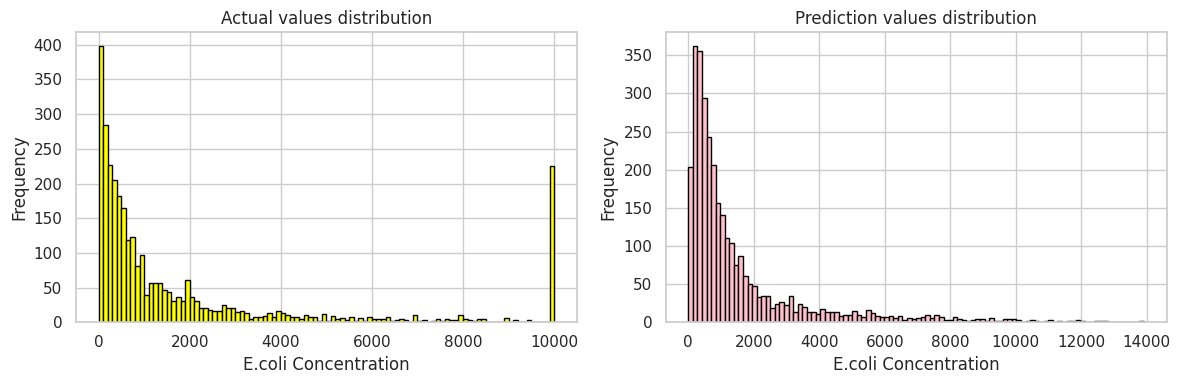

In [54]:
# Generate the distribution data in histogram format
pre = preds

# Plotting a histogram
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
 
axes[0].hist(y_test1, bins=100, color='Yellow', edgecolor='black')
axes[0].set_title('Actual values distribution')
 
axes[1].hist(pre, bins=100, color='Pink', edgecolor='black')
axes[1].set_title('Prediction values distribution')
 
# Adding labels and title
for ax in axes:
    ax.set_xlabel('E.coli Concentration')
    ax.set_ylabel('Frequency')
    
# Adjusting layout for better spacing
plt.tight_layout()
 
# Display the figure
plt.show()

# Precision-Recall and ROC curves 

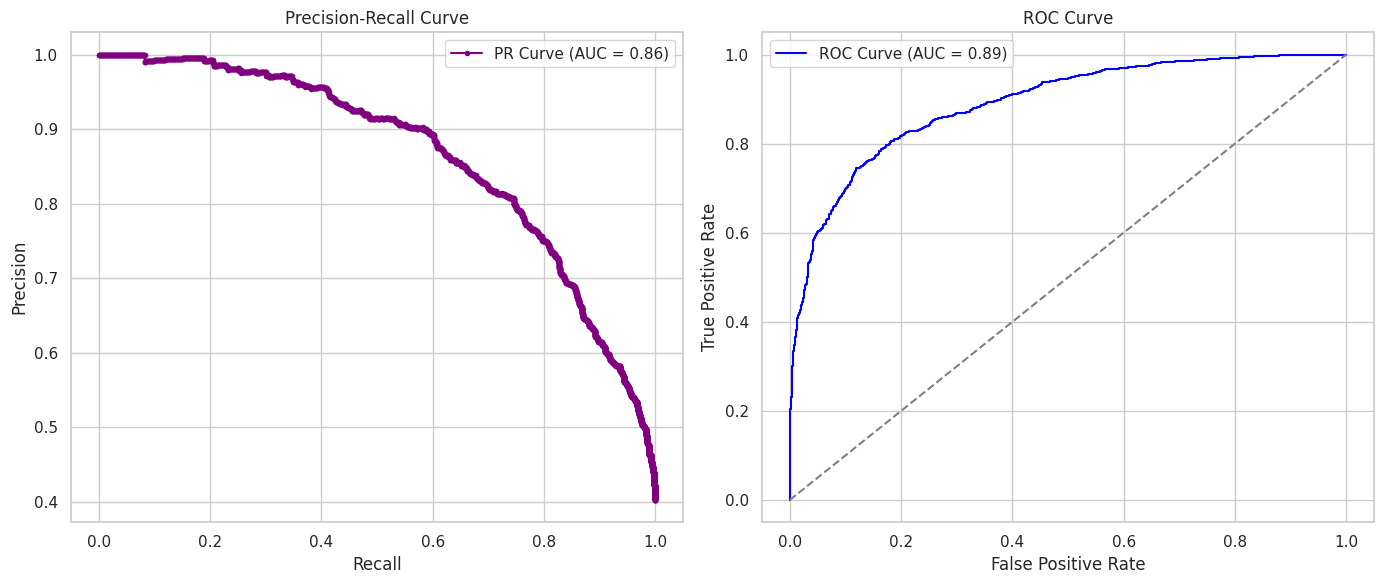

In [55]:
# Define a threshold to create binary classification labels
# y_true > 1000 as the positive class for E.coli
binary_true = (y_test > 1000).astype(int)

# Precision-Recall Curve
precision_xgr, recall_xgr, pr_thresholds_xgr = precision_recall_curve(binary_true, preds)
pr_auc_xgr = auc(recall_xgr, precision_xgr)

# ROC Curve
fpr_xgr, tpr_xgr, roc_thresholds_xgr = roc_curve(binary_true, preds)
roc_auc_xgr = auc(fpr_xgr, tpr_xgr)

# 4. Plotting
plt.figure(figsize=(14, 6))

# Precision-Recall Curve
plt.subplot(1, 2, 1)
plt.plot(recall_xgr, precision_xgr, label=f'PR Curve (AUC = {pr_auc_xgr:.2f})', marker='.', color='purple')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

# ROC Curve
plt.subplot(1, 2, 2)
plt.plot(fpr_xgr, tpr_xgr, color='blue', label=f'ROC Curve (AUC = {roc_auc_xgr:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Other acuuracy metrics

three other Accuracy metrics. 

In [56]:
tst = y_test1.copy()
pre = preds.copy()

tst[tst<10] = 10
tst[tst>10000] = 10000
pre[pre<10] = 10
pre[pre>10000] = 10000

# Accuracy = (1 - sMAPE) * 100
print("Accuracy = (1 - sMAPE) * 100 = %.5f" % (( np.mean(np.abs(tst - pre) / ((np.abs(tst)+np.abs(pre))/2))) * 100),"%")

# Percentage of estimations within a certain error margin.
# Accuracy = (number of estimations with error < thr)/ all samples
thr = 0.4
tst = np.log10(tst)
pre = np.log10(pre)
error = (np.abs(pre - tst))
print("Accuracy = number of estimations with error < 0.4)/ all samples = %.5f" % ((error < thr).sum()/len(error)*100),"%")

# threshold based accuracy. precentage of estimation with error < thr of actual value
thr = 0.05
error = np.abs(pre - tst) < 0.2 * tst
print("Accuracy = precentage of estimation with error < 20 percent of actual value = %.5f" % (error.sum()/len(tst)*100),"%")

Accuracy = (1 - sMAPE) * 100 = 63.87142 %
Accuracy = number of estimations with error < 0.4)/ all samples = 70.91545 %
Accuracy = precentage of estimation with error < 20 percent of actual value = 81.43675 %


# SHAP Analysis

In [57]:
shap_values_all = []
for model in trained_models:
    explainer = shap.Explainer(model, X_train)
    shap_values = explainer.shap_values(X_test)
    shap_values_all.append(shap_values)

 97%|=================== | 3049/3146 [00:18<00:00]       

In [47]:
mean_shap_values = np.mean([val for val in shap_values_all], axis=0)

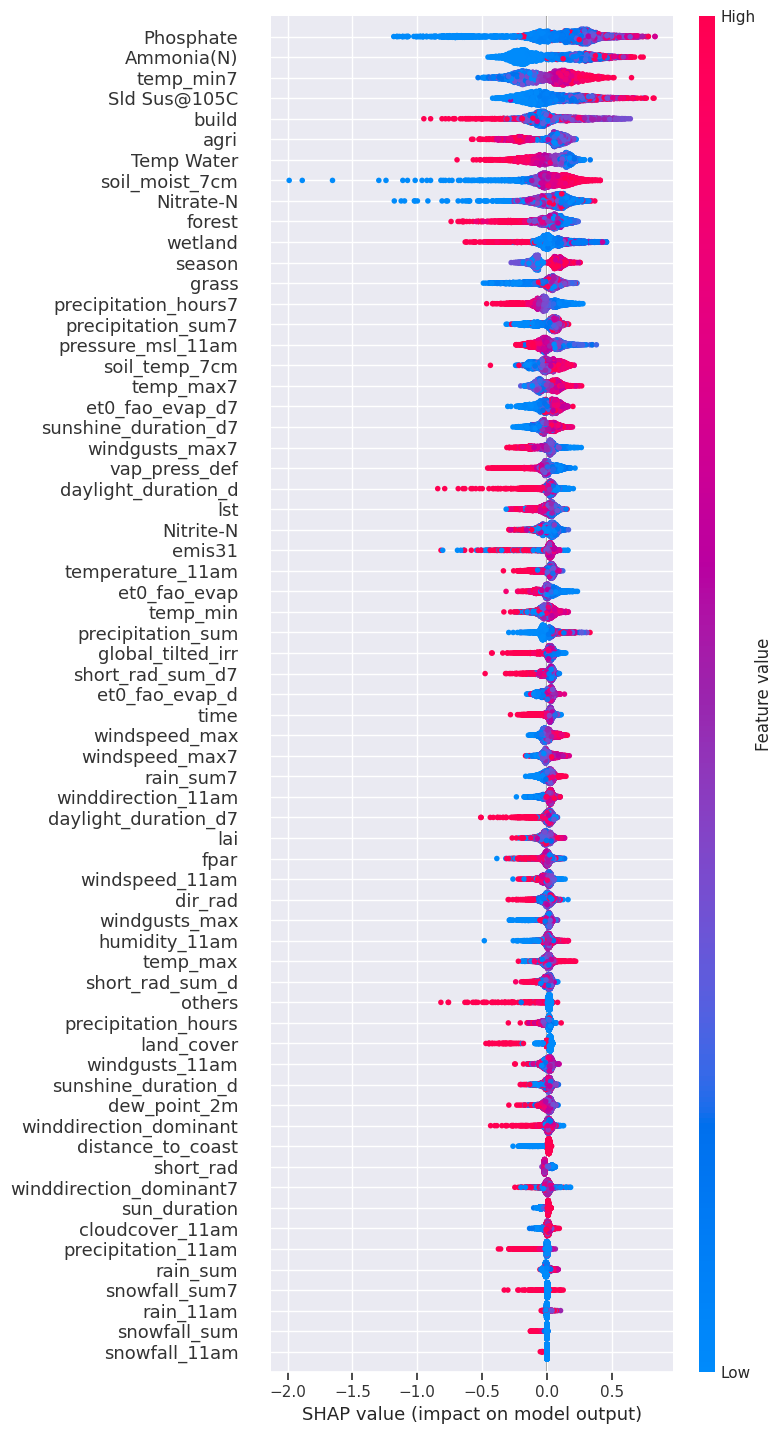

In [52]:
shap.summary_plot(mean_shap_values, X_test,feature_names=X_test.columns,max_display=80,plot_size=0.2)

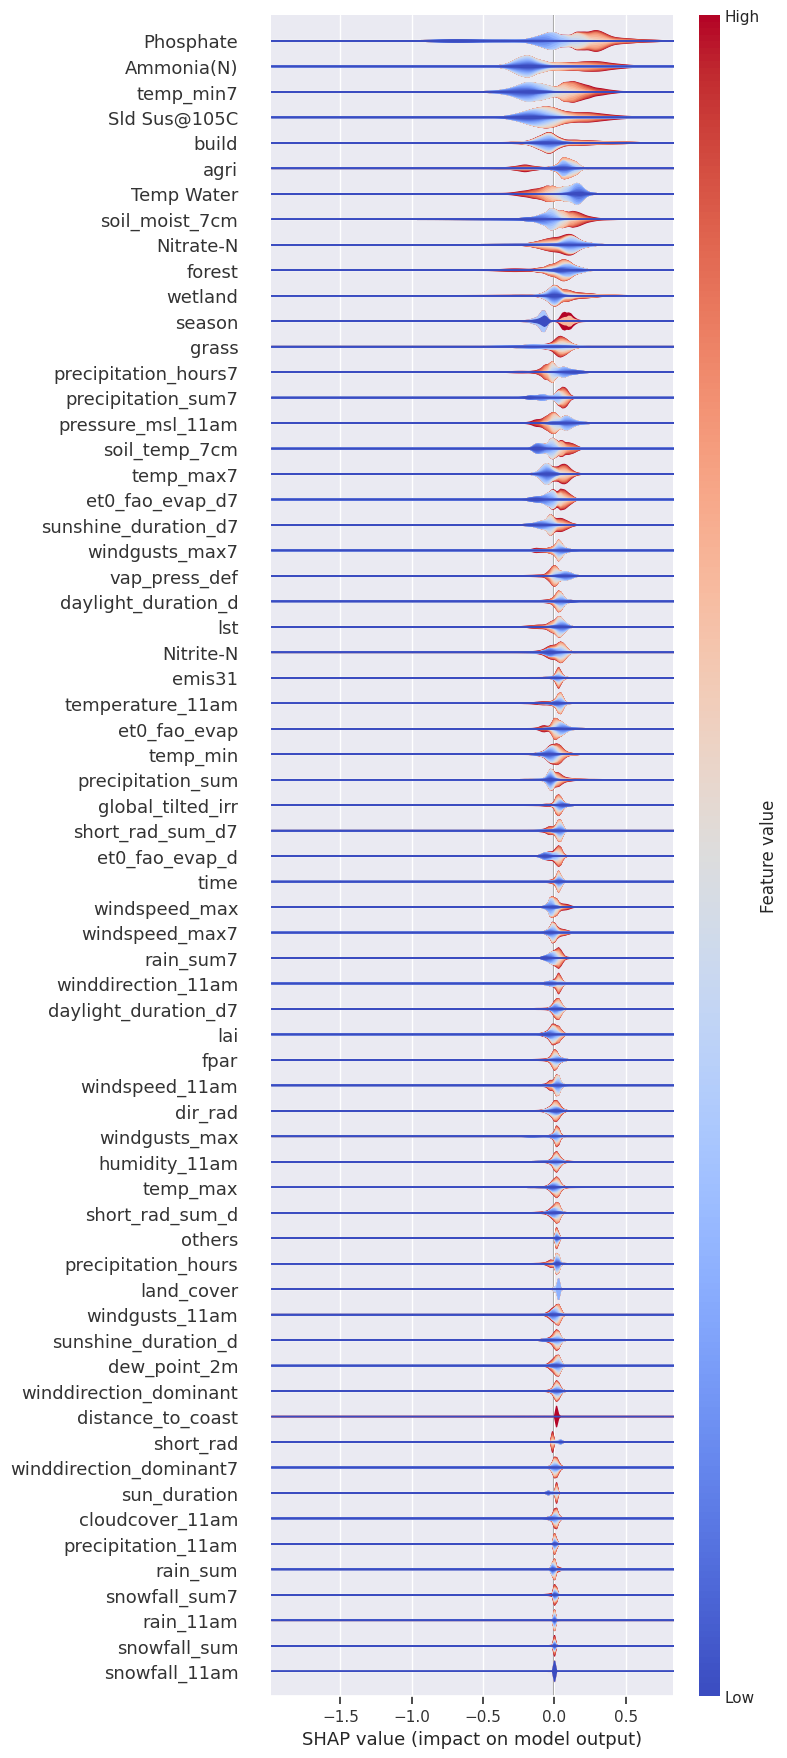

In [53]:
shap.summary_plot(mean_shap_values, X_test,feature_names=X_test.columns,
                  plot_type="layered_violin",max_display=80,plot_size=0.25) # bar,violin

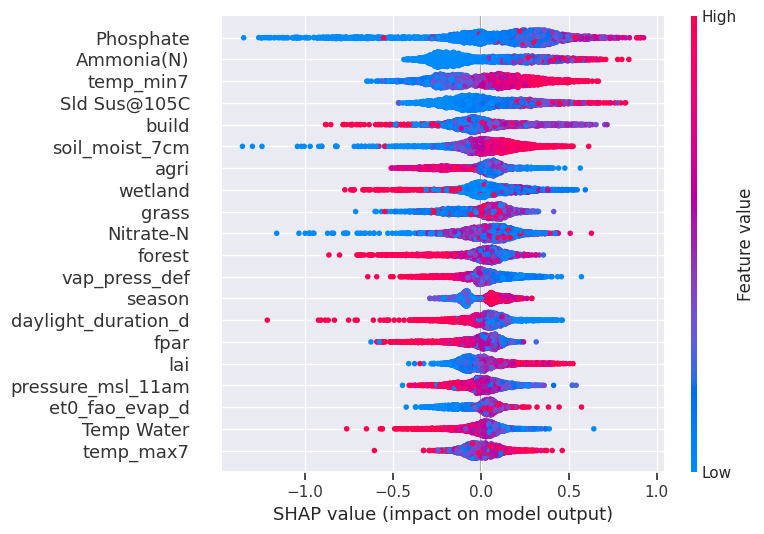

In [54]:
# Analyse single fold
shap.summary_plot(shap_values_all[0], X_test,feature_names=X_test.columns,plot_size=0.2) # ,max_display=80

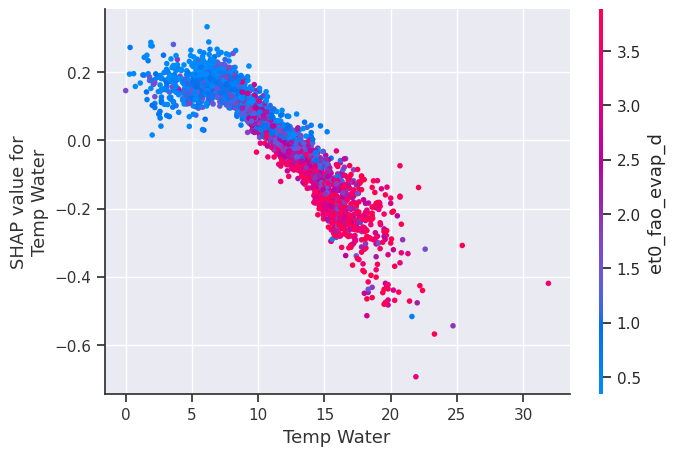

In [55]:
shap.dependence_plot("Temp Water",mean_shap_values,X_test,feature_names=X_test.columns)

In [99]:
X_test_df = pd.DataFrame(X_test, columns=X_test.columns)
X_train_df = pd.DataFrame(X_train, columns=X_train.columns)

shap_values_wf = []
for model in trained_models:
    explainer_wf = shap.Explainer(model, X_train_df)
    shap_values = explainer_wf(X_test_df)
    shap_values_wf.append(shap_values)

 99%|===================| 3110/3146 [00:20<00:00]        

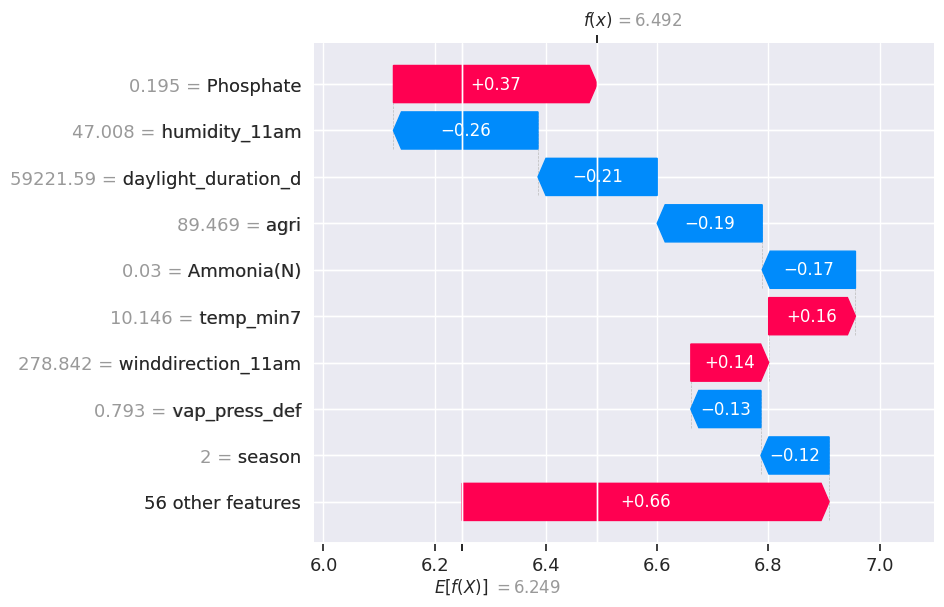

In [117]:
# Visualizes how each feature contributes to the final prediction for a sample:
shap.plots.waterfall(shap_values_wf[0][0])  # Replace first [0] with value (0,10) which represent each fold

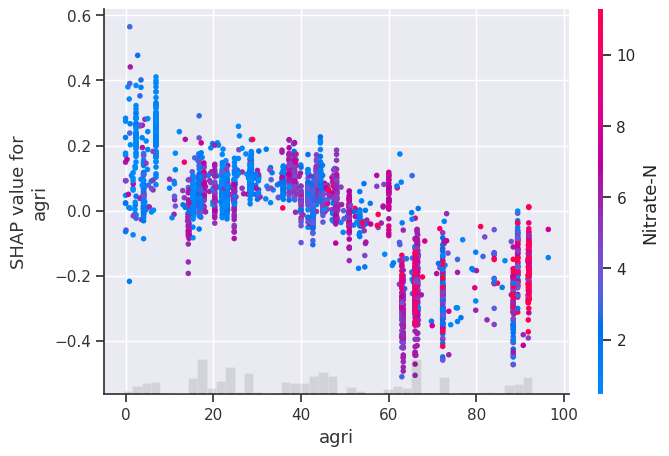

In [119]:
# To show a feature’s SHAP values interacting with another feature
shap.plots.scatter(shap_values_wf[0][:, "agri"],color=shap_values_wf[0][:, "Nitrate-N"]) # Replace first [0] with value (0,10) which represent each fold

# E.coli Classifiers

Unlike the estimators, this section focuses on classification tasks, predicting whether E.coli levels exceed a certain threshold (e.g., high vs. low levels).

In [58]:
# Run this cell only if Temporal Split 
y2 = datasetxxt['E.coli C-MF']
thr = 1000
y2 = y2.astype(float).apply(lambda x: (0 if (x <thr)
                                     else 1))
X_train, X_test, y_train, y_test = train_test_split(X, y2, test_size=0.15, random_state=42)

In [232]:
# Run this cell only if Geographical Split 
y_train2 = y_train.copy()
y_test2 = y_test.copy()

In [236]:
# Run this cell only if Geographical Split 
thr = 1000 # change thr and run fron this cell onward
y_train = pd.DataFrame({'E.coli C-MF': y_train2}).astype(float).apply(lambda x: [0 if y < thr else 1 for y in x])
y_test = pd.DataFrame({'E.coli C-MF': y_test2}).astype(float).apply(lambda x: [0 if y < thr else 1 for y in x])

In [59]:
Scaler = MinMaxScaler().fit(X_train) # RobustScaler
X_trainN = Scaler.transform(X_train)
X_testN = Scaler.transform(X_test)

## RandomForestClassifier

In [60]:
rfc = RandomForestClassifier(n_estimators=250)
rfc.fit(X_trainN,y_train)
rfc_pred = rfc.predict(X_testN)
print(classification_report(y_test,rfc_pred))

              precision    recall  f1-score   support

           0       0.79      0.91      0.85      1837
           1       0.84      0.66      0.74      1309

    accuracy                           0.81      3146
   macro avg       0.81      0.79      0.79      3146
weighted avg       0.81      0.81      0.80      3146



[[1669  168]
 [ 442  867]]
0.8061029879211697


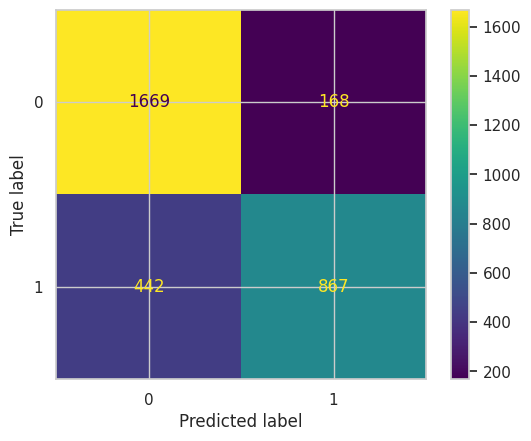

In [61]:
print(confusion_matrix(y_test,rfc_pred))
print((confusion_matrix(y_test,rfc_pred)[1][1] + confusion_matrix(y_test,rfc_pred)[0][0])/confusion_matrix(y_test,rfc_pred).sum())
ConfusionMatrixDisplay.from_estimator(rfc,X_testN,y_test)

In [62]:
rfc = RandomForestClassifier()
param_grid = { 
    'n_estimators': [300],
    'max_features': ['sqrt'],
    'max_depth' : [18],
    'criterion' :['entropy']
}
CV_rfc=RandomForestClassifier(random_state=42, max_features='sqrt', n_estimators= 300, max_depth=18, criterion='entropy')
#CV_rfc = GridSearchCV(estimator=rfc, param_grid=param_grid, n_jobs=-1, cv= 5, verbose=2)
CV_rfc.fit(X_trainN,y_train)

rfc_pred = CV_rfc.predict(X_testN)
print(classification_report(y_test,rfc_pred))
print(confusion_matrix(y_test,rfc_pred))
print(accuracy_score(y_test,rfc_pred))
#print(CV_rfc.best_params_)

# this result is for no normalization

              precision    recall  f1-score   support

           0       0.79      0.91      0.84      1837
           1       0.83      0.66      0.74      1309

    accuracy                           0.80      3146
   macro avg       0.81      0.78      0.79      3146
weighted avg       0.81      0.80      0.80      3146

[[1664  173]
 [ 446  863]]
0.8032422123331214


## ExtraTreesClassifier

In [63]:
etc = ExtraTreesClassifier(n_estimators=250)
etc.fit(X_trainN,y_train)
etc_pred = etc.predict(X_testN)
print(classification_report(y_test,etc_pred))

              precision    recall  f1-score   support

           0       0.76      0.85      0.80      1837
           1       0.74      0.63      0.68      1309

    accuracy                           0.76      3146
   macro avg       0.75      0.74      0.74      3146
weighted avg       0.75      0.76      0.75      3146



[[1556  281]
 [ 489  820]]
0.7552447552447552


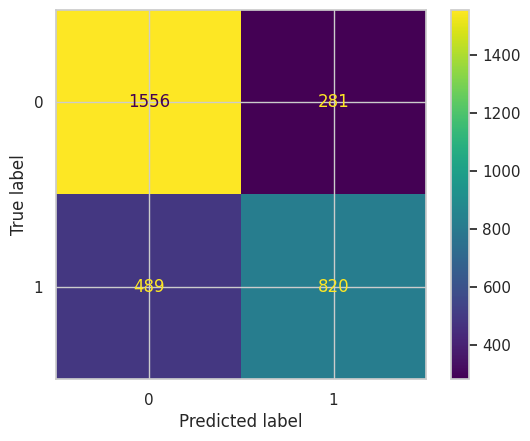

In [64]:
print(confusion_matrix(y_test,etc_pred))
print((confusion_matrix(y_test,etc_pred)[1][1] + confusion_matrix(y_test,etc_pred)[0][0])/confusion_matrix(y_test,etc_pred).sum())
ConfusionMatrixDisplay.from_estimator(etc,X_testN,y_test)

## KNeighborsClassifier

The K-Nearest Neighbors (KNN) algorithm classifies data points based on the majority class of their closest neighbors.

In [65]:
# KNeighborsClassifier
knc = KNeighborsClassifier(n_neighbors=100)
knc.fit(X_trainN,y_train)
knc_pred = knc.predict(X_testN)
print(classification_report(y_test,knc_pred))

              precision    recall  f1-score   support

           0       0.68      0.86      0.76      1837
           1       0.69      0.43      0.53      1309

    accuracy                           0.68      3146
   macro avg       0.69      0.65      0.65      3146
weighted avg       0.69      0.68      0.67      3146



[[1586  251]
 [ 741  568]]
0.6846789574062301


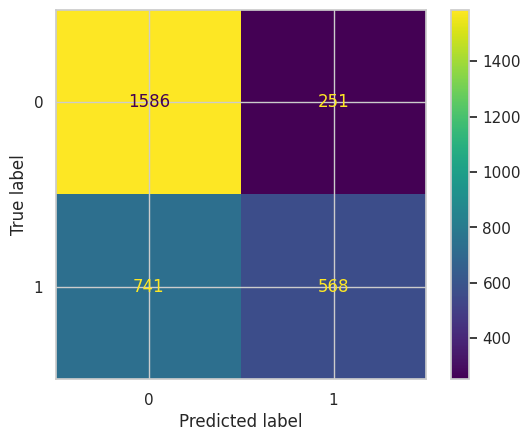

In [66]:
print(confusion_matrix(y_test,knc_pred))
print((confusion_matrix(y_test,knc_pred)[1][1] + confusion_matrix(y_test,knc_pred)[0][0])/confusion_matrix(y_test,knc_pred).sum())
ConfusionMatrixDisplay.from_estimator(knc,X_testN,y_test)

## SVC Model

Support Vector Classification (SVC) finds the best boundary (hyperplane) that separates different classes. It works well for binary classification tasks.

In [67]:
svc = SVC(C= 10, gamma= 0.6, kernel= 'rbf')
svc.fit(X_trainN,y_train)
svc_pred = svc.predict(X_testN)
print(classification_report(y_test,svc_pred))

              precision    recall  f1-score   support

           0       0.76      0.85      0.80      1837
           1       0.75      0.62      0.68      1309

    accuracy                           0.76      3146
   macro avg       0.76      0.74      0.74      3146
weighted avg       0.76      0.76      0.75      3146



[[1568  269]
 [ 491  818]]
0.7584233947870311


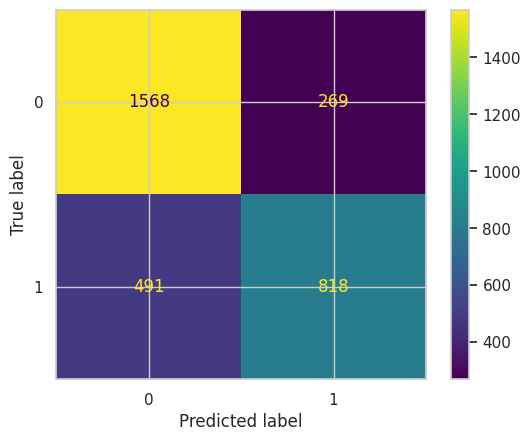

In [68]:
print(confusion_matrix(y_test,svc_pred))
print(accuracy_score(y_test,svc_pred))
ConfusionMatrixDisplay.from_estimator(svc,X_testN,y_test)

## XGBClassifier

This applies XGBoost for classification, effectively handling complex patterns in E. coli presence.

              precision    recall  f1-score   support

           0       0.80      0.89      0.84      1837
           1       0.81      0.70      0.75      1309

    accuracy                           0.81      3146
   macro avg       0.81      0.79      0.80      3146
weighted avg       0.81      0.81      0.80      3146

[[1629  208]
 [ 398  911]]
0.8073744437380801
              precision    recall  f1-score   support

           0       0.80      0.89      0.84      1837
           1       0.81      0.70      0.75      1309

    accuracy                           0.81      3146
   macro avg       0.81      0.79      0.80      3146
weighted avg       0.81      0.81      0.80      3146

0.8073744437380801


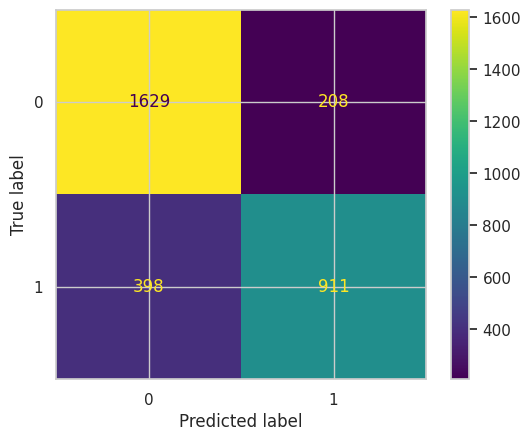

In [69]:
# XGBClassifier
param = {
    'eta': 0.17, 
    'max_depth': 15,  
    'num_class': 1,
    "min_child_weight": 5,
    "gamma": 0.20,
    "colsample_bytree": 0.7,
    'n_estimators': 40}
xgc = XGBClassifier(objective='binary:logistic', **param)
#s = np.array([0,1,2,3,4,5,6,7,8,9,10,11,27,25,24,23,13])
xgc.fit(X_trainN,y_train)
xgc_pred = xgc.predict(X_testN)
print(classification_report(y_test,xgc_pred))
print(confusion_matrix(y_test,xgc_pred))
print(accuracy_score(y_test,xgc_pred))

#save model
"""
with open('modelxgb.pkl', 'wb') as f:
    joblib.dump(xgc, f)
    """

print(classification_report(y_test,xgc_pred))
print(accuracy_score(y_test,xgc_pred))
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test,xgc_pred)).plot()

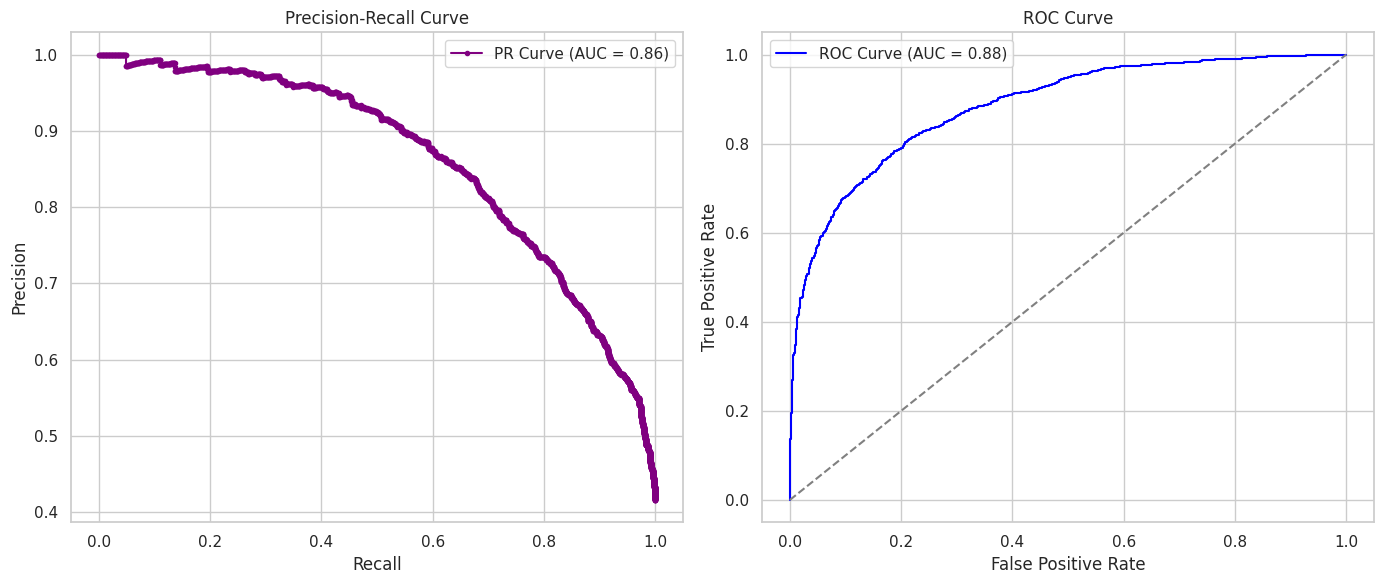

In [70]:
# Get the probobility
y_prob = xgc.predict_proba(X_testN)[:,1]

# Precision-Recall Curve
precision_xgc, recall_xgc, pr_thresholds_xgc = precision_recall_curve(y_test, y_prob)
pr_auc_xgc = auc(recall_xgc, precision_xgc)

# ROC Curve
fpr_xgc, tpr_xgc, roc_thresholds_xgc = roc_curve(y_test, y_prob)
roc_auc_xgc = auc(fpr_xgc, tpr_xgc)

# 4. Plotting
plt.figure(figsize=(14, 6))

# Precision-Recall Curve
plt.subplot(1, 2, 1)
plt.plot(recall_xgc, precision_xgc, label=f'PR Curve (AUC = {pr_auc_xgc:.2f})', marker='.', color='purple')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

# ROC Curve
plt.subplot(1, 2, 2)
plt.plot(fpr_xgc, tpr_xgc, color='blue', label=f'ROC Curve (AUC = {roc_auc_xgc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## XGBClassifier with cross-validation

Similar to the regression model, this classifier uses cross-validation to improve generalization.

Mean Accuracy: 0.8053
Mean F1 Score: 0.8012
Mean Recall: 0.8053
Mean Precision: 0.8082
Mean False Positives (FP): 0.05756516211061665
Mean False Negatives (FN): 0.13712650985378258
Accuracy: 0.8077
F1 Score: 0.8029
Recall: 0.8077
Precision: 0.8125
False Positives (FP): 0.05756516211061665
False Negatives (FN): 0.13712650985378258


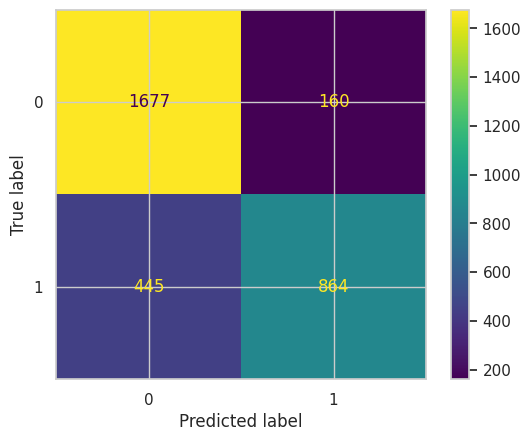

In [71]:
# Initialize K-Fold Cross-Validation
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score,recall_score,precision_score
k = 10  # Number of folds
kf = KFold(n_splits=k, shuffle=False)  # shuffle=True, random_state=42

# Lists to store metrics for each fold
rmse_list = []
mae_list = []
accuracy_list = []
f1_list = []
recall_list = []
precision_list = []
fp_list = []
fn_list = []
y_pred_all = []
y_test_all = []
y_probs = []

# Perform K-Fold Cross-Validation
trained_models = []
for i, (train_index, val_index) in enumerate(kf.split(X_trainN)):
    X_train_fold, X_val_fold = X_trainN[train_index], X_trainN[val_index]
    # add .iloc in case of Geographical split to y_train.reset_index(drop=True).iloc[train_index]
    y_train_fold, y_val_fold = y_train.reset_index(drop=True).iloc[train_index], y_train.reset_index(drop=True).iloc[val_index] 
    
    # Initialize and train the model
    model = XGBClassifier(
    objective='binary:logistic', 
    n_estimators=40,
    learning_rate=0.1,
    gamma=0.2,
    max_depth=15,
    colsample_bytree=0.7,
    min_child_weight=10,
    num_class=1,
    eta=0.17, 
    early_stopping_rounds=20, # remove in case of early stopping
    eval_metric='logloss', # remove in case of early stopping
    random_state=42
    )
    # Fit the model without early stopping
    #model.fit(X_train_fold, y_train_fold)
    

    # Fit the model with early stopping
    model.fit(X_train_fold, y_train_fold, eval_set=[(X_val_fold, y_val_fold)], verbose=False)
   

    # Evaluate on the test set
    y_pred = model.predict(X_testN)
    
    # Get the probobility
    y_prob = model.predict_proba(X_testN)[:,1]
    
    trained_models.append(model)   
    #joblib.dump(model, f'Model/xgbc_f{i}_Tmp_adv_{thr}.joblib')
   
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted')
   
    # Confusion Matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
   
    # Append metrics to lists
    accuracy_list.append(accuracy)
    f1_list.append(f1)
    recall_list.append(recall)
    precision_list.append(precision)
    fp_list.append(fp)
    fn_list.append(fn)
    y_pred_all.append(y_pred)
    y_probs.append(y_prob)
    y_test_all.append(y_test)

# Calculate mean of each metric
mean_accuracy = np.mean(accuracy_list)
mean_f1 = np.mean(f1_list)
mean_recall = np.mean(recall_list)
mean_precision = np.mean(precision_list)
mean_fp = np.mean(fp_list)/(tn+fp+fn+tp)
mean_fn = np.mean(fn_list)/(tn+fp+fn+tp)
# Display Results
print(f"Mean Accuracy: {mean_accuracy:.4f}")
print(f"Mean F1 Score: {mean_f1:.4f}")
print(f"Mean Recall: {mean_recall:.4f}")
print(f"Mean Precision: {mean_precision:.4f}")
print(f"Mean False Positives (FP): {mean_fp}")
print(f"Mean False Negatives (FN): {mean_fn}")

# Calculate metrics 
accuracy = accuracy_score(y_test, np.mean(np.array(y_pred_all), axis=0).round())
f1 = f1_score(y_test, np.mean(np.array(y_pred_all), axis=0).round(), average='weighted')
recall = recall_score(y_test, np.mean(np.array(y_pred_all), axis=0).round(), average='weighted')
precision = precision_score(y_test, np.mean(np.array(y_pred_all), axis=0).round(), average='weighted')
# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, np.mean(np.array(y_pred_all), axis=0).round()).ravel()
precent_fp = np.mean(fp_list)/(tn+fp+fn+tp)
precent_fn = np.mean(fn_list)/(tn+fp+fn+tp)
# Display Results
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"False Positives (FP): {precent_fp}")
print(f"False Negatives (FN): {precent_fn}")

#cm = confusion_matrix(np.array(y_test_all).reshape(-1), np.array(y_pred_all).reshape(-1)) # top up on each model fold output
cm = confusion_matrix(np.array(y_test).reshape(-1), np.mean(np.array(y_pred_all), axis=0).round())
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

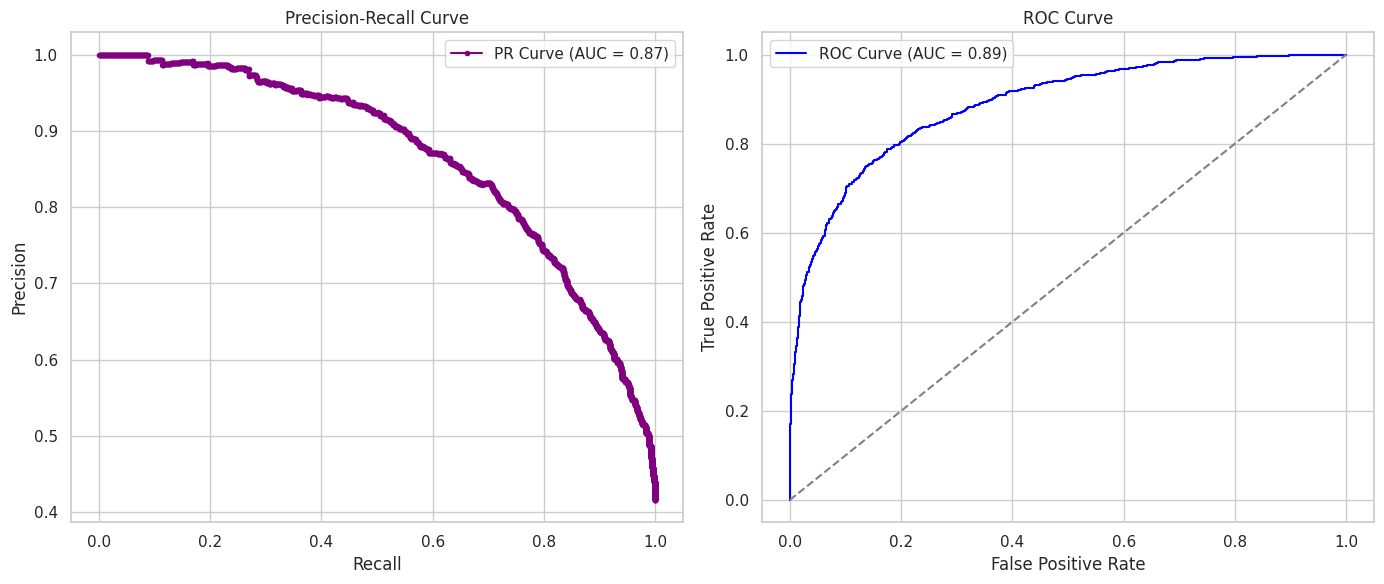

In [72]:
# Precision-Recall Curve
precision_xgc, recall_xgc, pr_thresholds_xgc = precision_recall_curve(np.array(y_test).reshape(-1), np.mean(np.array(y_probs),axis=0))
pr_auc_xgc = auc(recall_xgc, precision_xgc)

# ROC Curve
fpr_xgc, tpr_xgc, roc_thresholds_xgc = roc_curve(np.array(y_test).reshape(-1), np.mean(np.array(y_probs),axis=0))
roc_auc_xgc = auc(fpr_xgc, tpr_xgc)

# 4. Plotting
plt.figure(figsize=(14, 6))

# Precision-Recall Curve
plt.subplot(1, 2, 1)
plt.plot(recall_xgc, precision_xgc, label=f'PR Curve (AUC = {pr_auc_xgc:.2f})', marker='.', color='purple')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

# ROC Curve
plt.subplot(1, 2, 2)
plt.plot(fpr_xgc, tpr_xgc, color='blue', label=f'ROC Curve (AUC = {roc_auc_xgc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Map on Geographical Distribution of Classification Performance

This final step visualizes the model’s accuracy across different geographical locations, helping to identify spatial trends in E.coli classification accuracy.

In [73]:
# Run this cell only for Temporal split 
XX = datasetxxt.drop(['E.coli C-MF','date'], axis=1)
XX_train, XX_test, yy_train, yy_test = train_test_split(XX, y, test_size=0.15, random_state=42)

In [74]:
# On result["result"]: zero means correct classification and one means worng classification

result = pd.concat([y_test, XX_test[["Lat","Long"]]], axis=1) # for Temporal split keep this line
#result = pd.concat([y_test, test[["Lat","Long"]]], axis=1) # for Geographical split keep this line
result["result"] = (result["E.coli C-MF"] ^ xgc_pred)
result.head()

,E.coli C-MF,Lat,Long,result
4003,0,53.305520,-0.350670,0
11282,0,52.130081,1.391167,0
7955,1,53.825086,-2.797749,0
14000,1,51.071089,-1.779702,1
1489,1,50.352183,-3.978359,1


In [75]:
# map show locations green >75%, 75%> yellow >65%, 65%> orange >55% and 55%> red of accuracy on classification
# with 4 different size of counts
import folium
import pandas as pd
import branca.colormap as cm
from scipy import stats
from utils import getradius2

grouped_data = result[['result','Long','Lat']]
grouped_data = grouped_data.dropna().reset_index(drop=True)
grouped_data = grouped_data.groupby(["Lat", "Long"]).agg(
    ecoli_mean = ("result","mean"),
    ecoli_count = ("result","count")
).reset_index()

# Sample data generation (Replace this with your actual DataFrame)
df = grouped_data
df = df[df['Lat'] > 49.90] #Drop unwanted rows
df = df[df['Lat'] < 61] #Drop unwanted rows


m = folium.Map(location=[df['Lat'].median(), df['Long'].median()], zoom_start=5)

# green >75%, 75%> yellow >65%, 65%> orange >55% and 55%> red 
colormap = cm.LinearColormap(colors=['green', 'yellow', 'orange', 'red'], vmin=0.2, vmax=0.5)

# Add circle markers for each location
for index, row in df.iterrows():
    folium.CircleMarker(
        location=[row['Lat'], row['Long']],
        radius= getradius2(row['ecoli_count']),  # Scale the radius according to the counts
        color=colormap(row['ecoli_mean']),  # Assign color based on intensity
        fill=True,
        fill_opacity=0.6,
        popup=f"Intensity: {row['ecoli_mean']}"
    ).add_to(m)

# Save map to an HTML file
m.save('ecoli_t.html')

m